# 03 Product Category Analysis

## Project Objectives

- Identify high-performing and low-performing product categories
- Analyse category sales, satisfaction, and customer preference
- Support category operation and inventory decisions with data evidence

## 1. Data Loading & Initial Exploration

In [2]:
# Import library code units
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False

### 1.1 Category-level Data Loading

To analyse product category performance, the first step is to load a category-level aggregated dataset from the MySQL data warehouse. This table summarises the key business indicators for each product category, including sales volume, customer count, revenue, freight cost, review score, bad review rate, repurchase proxy, and category lifecycle. Since the data is already aggregated at the category level, each row represents one product category rather than one individual order or one customer.

In [3]:
# load category-level aggregated data from MySQL
# each row in this dataset represents one product category
from src.utils.db import get_engine

engine = get_engine()

sql_category = """
SELECT *
FROM view_category_analysis
"""

df_category = pd.read_sql(sql_category, engine)

print(df_category.shape)
df_category.head()

(73, 14)


,category,order_count,customer_count,total_revenue,total_gmv,avg_price,avg_freight,avg_review_score,bad_review_rate,avg_comment_len,repeat_rate,first_sale_date,last_sale_date,category_lifetime_days
0,agro_industria_e_comercio,182,182,72530.47,78374.07,342.124858,27.564151,4.0000,16.03774,20.7028,1.0,2017-01-23 07:03:04,2018-08-26 07:57:32,580
1,alimentos,450,450,29393.41,36664.44,57.634137,14.256922,4.2134,13.00813,22.6199,1.0,2016-10-10 11:22:36,2018-08-29 11:06:11,688
2,alimentos_bebidas,227,227,15218.47,19753.64,54.546487,16.255090,4.3091,8.00000,20.7891,1.0,2017-03-05 01:03:51,2018-08-23 19:57:47,536
3,artes,202,202,24202.64,28247.81,115.802105,19.354880,3.9515,17.96117,31.5777,1.0,2017-03-01 10:56:53,2018-08-27 19:37:48,544
4,artes_e_artesanato,23,23,1814.01,2184.14,75.583750,15.422083,4.1250,12.50000,43.4167,1.0,2017-05-08 12:01:54,2018-08-24 12:41:33,473


In [4]:
# View the fields and data types of the df_category table.
df_category.info()

<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   category                73 non-null     str           
 1   order_count             73 non-null     int64         
 2   customer_count          73 non-null     int64         
 3   total_revenue           73 non-null     float64       
 4   total_gmv               73 non-null     float64       
 5   avg_price               73 non-null     float64       
 6   avg_freight             73 non-null     float64       
 7   avg_review_score        73 non-null     float64       
 8   bad_review_rate         73 non-null     float64       
 9   avg_comment_len         73 non-null     float64       
 10  repeat_rate             73 non-null     float64       
 11  first_sale_date         73 non-null     datetime64[us]
 12  last_sale_date          73 non-null     datetime64[us]
 13  cat

In [5]:
df_category.columns.tolist()

['category',
 'order_count',
 'customer_count',
 'total_revenue',
 'total_gmv',
 'avg_price',
 'avg_freight',
 'avg_review_score',
 'bad_review_rate',
 'avg_comment_len',
 'repeat_rate',
 'first_sale_date',
 'last_sale_date',
 'category_lifetime_days']

In [6]:
df_category["category"].nunique()

73

The category-level dataset contains aggregated information for 73 product categories and 14 variables. This confirms that the table is structured at the category level rather than the transaction level. Such a dataset is suitable for high-level comparative analysis across categories, such as ranking categories by revenue, identifying high- and low-performing groups, and constructing category strategy frameworks such as Pareto analysis and quadrant classification.

### 1.2 Order-level Data Loading
In addition to the category-level aggregated table, this project also requires a more detailed order-level dataset. The category-level table is useful for overall comparison, but it does not preserve transaction-level variation. To analyse pricing patterns, customer preference, delivery-related variables, satisfaction behaviour, and temporal trends, an order-item level dataset is loaded by joining product, order, review, and customer information from the warehouse.

In [7]:
# load order_item level data for detailed category analysis
# each row in this dataset represents an order item linked to a category
sql_orders = """
SELECT
    p.category,
    oi.order_id,
    o.user_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    oi.gmv,
    o.purchase_ts,
    o.delivered_days,
    r.review_score,
    r.review_comment_len,
    u.state AS customer_state
FROM fact_order_item oi
JOIN dim_product p
    ON oi.product_id = p.product_id
JOIN fact_order o
    ON oi.order_id = o.order_id
LEFT JOIN fact_review r
    ON o.order_id = r.order_id
LEFT JOIN dim_user u
    ON o.user_id = u.user_id
WHERE p.category IS NOT NULL
"""

# read sql result into pandas dataframe
df_orders = pd.read_sql(sql_orders, engine)

# check dataset shape
print(df_orders.shape)

# preview the first few rows
df_orders.head()

(111426, 12)


,category,order_id,user_id,product_id,price,freight_value,gmv,purchase_ts,delivered_days,review_score,review_comment_len,customer_state
0,cool_stuff,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,2017-09-13 08:59:02,7.0,5.0,46.0,RJ
1,pet_shop,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,2017-04-26 10:53:06,16.0,4.0,0.0,SP
2,moveis_decoracao,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,2018-01-14 14:33:31,8.0,5.0,90.0,MG
3,perfumaria,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,2018-08-08 10:00:35,6.0,4.0,0.0,SP
4,ferramentas_jardim,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,2017-02-04 13:57:51,25.0,5.0,39.0,SP


The order-level dataset preserves detailed transaction records and is much larger than the aggregated category-level dataset. Each row corresponds to an order item associated with a product category, customer, and review context. This dataset is necessary for downstream analyses that cannot be carried out at the grouped category level, including price distribution analysis, category preference by user segment, monthly sales trend analysis, state-level category comparison, and selected statistical tests.

### 1.3 Data Structure Check
Before starting the formal analysis, it is necessary to check the structure and data quality of the two datasets. This includes examining variable types, identifying data fields, and check whether important variables contain missing values. These checks help ensure that the following analysis is based on correctly formatted and reliable data.

In [8]:
# check the structure, data types, and non-null counts of both datasets

print("Category-level dataset info:")
df_category.info()

print("\n" + "=" * 60 + "\n")

print("Order-level dataset info:")
df_orders.info()

Category-level dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   category                73 non-null     str           
 1   order_count             73 non-null     int64         
 2   customer_count          73 non-null     int64         
 3   total_revenue           73 non-null     float64       
 4   total_gmv               73 non-null     float64       
 5   avg_price               73 non-null     float64       
 6   avg_freight             73 non-null     float64       
 7   avg_review_score        73 non-null     float64       
 8   bad_review_rate         73 non-null     float64       
 9   avg_comment_len         73 non-null     float64       
 10  repeat_rate             73 non-null     float64       
 11  first_sale_date         73 non-null     datetime64[us]
 12  last_sale_date          73 non-nul

In [9]:
# check missing values in both datasets

print("Missing values in df_category:")
print(df_category.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_orders:")
print(df_orders.isnull().sum())

Missing values in df_category:
category                  0
order_count               0
customer_count            0
total_revenue             0
total_gmv                 0
avg_price                 0
avg_freight               0
avg_review_score          0
bad_review_rate           0
avg_comment_len           0
repeat_rate               0
first_sale_date           0
last_sale_date            0
category_lifetime_days    0
dtype: int64


Missing values in df_orders:
category                 0
order_id                 0
user_id                  0
product_id               0
price                    0
freight_value            0
gmv                      0
purchase_ts              0
delivered_days        2399
review_score          1572
review_comment_len    1572
customer_state           0
dtype: int64


### Data Structure Check analysis and summary
The data structure check shows that the category-level dataset is clean, compact, and already well aggregated. It contains 73 product categories and 14 variables, including sales indicators, customer-related metrics, review-related measures, and lifecycle information. No missing values are found in this dataset, and both `first_sale_date` and `last_sale_date` have already been correctly recognised as datetime variables. This means the category-level table is ready for direct use in category comparison, ranking analysis, Pareto analysis, and quadrant-based strategic classification.

The order-level dataset contains 111,426 transaction records and 12 variables, which provide a much more detailed view of category behaviour. Most key business fields, including category, order ID, user ID, product ID, price, freight value, GMV, purchase timestamp, and customer state, are complete. The `purchase_ts` field has also been correctly stored as a datetime variable, which is suitable for later time-series analysis.

However, some missing values are present in the order-level dataset. Specifically, `delivered_days` contains 2,399 missing values, while `review_score` and `review_comment_len` each contain 1,572 missing values. These missing values are expected in an e-commerce context. Missing delivery information usually corresponds to orders that were not fully delivered or whose delivery status was incomplete at the time of data recording. Missing review-related values are also common because not all customers leave a review after purchase. Therefore, these missing values should not be removed blindly from the full dataset. Instead, they should be handled selectively depending on the analytical objective of each later section.

### 1.4 Data Preparation
Before moving to exploratory analysis, a small amount of data preparation is carried out. Since the full order-level dataset will support multiple downstream tasks, it is useful to prepare separate subsets for review-related analysis and delivery-related analysis.This avoids unnecessary global data deletion and keeps the original transaction dataset intact for later use.

In [10]:
# create analysis-specific subsets from the full order-level dataset
# keep the original df_orders unchanged

# subset for review-related analysis
df_review = df_orders[df_orders["review_score"].notna()].copy()

# subset for delivery-related analysis
df_delivery = df_orders[df_orders["delivered_days"].notna()].copy()

# subset for analysis requiring both review and delivery information
df_review_delivery = df_orders[
    df_orders["review_score"].notna() &
    df_orders["delivered_days"].notna()
].copy()

# check the size of each subset
print("Full order-level dataset:", df_orders.shape)
print("Review subset:", df_review.shape)
print("Delivery subset:", df_delivery.shape)
print("Review + Delivery subset:", df_review_delivery.shape)

Full order-level dataset: (111426, 12)
Review subset: (109854, 12)
Delivery subset: (109027, 12)
Review + Delivery subset: (107587, 12)


Instead of removing missing values from the full order-level dataset, task-specific subsets were created for later analysis. The full order-level dataset contains 111,426 records. Among them, 109,854 records have valid review information, 109,027 records have valid delivery duration information, and 107,587 records contain both review and delivery information. This result shows that the proportion of missing values is relatively small compared with the full dataset. Therefore, using separate subsets is a suitable strategy because it preserves the full transaction table for general category analysis while allowing more focused analysis when review or delivery variables are required.

## 2. Exploratory Data Analysis
Exploratory data analysis is carried out to understand the structure, distribution, and reliability of the category-level and order-level datasets before moving to business interpretation. This stage focuses on missing values, variable distributions, which help identify potential data issues and provide cntext for later comparative analysis.

### 2.1 Missing Value Summary and Interpretation
The first step in exploratory analysis is to review missing values in both datasets. Missing-value patterns are important because they affect which records can be used in later analysis, especially for review-related and delivery-related variables.

In [11]:
# summarise missing values in both datasets

missing_category = pd.DataFrame({
    "missing_count": df_category.isnull().sum(),
    "missing_pct": df_category.isnull().mean() * 100
})

missing_orders = pd.DataFrame({
    "missing_count": df_orders.isnull().sum(),
    "missing_pct": df_orders.isnull().mean() * 100
})

print("Missing values in category-level dataset:")
display(missing_category[missing_category["missing_count"] > 0])

print("\nMissing values in order-level dataset:")
display(missing_orders[missing_orders["missing_count"] > 0].sort_values("missing_count", ascending=False))

Missing values in category-level dataset:


,missing_count,missing_pct



Missing values in order-level dataset:


,missing_count,missing_pct
delivered_days,2399,2.152998
review_score,1572,1.410802
review_comment_len,1572,1.410802


### 2.1 Missing Value Summary and Interpretation — revised analysis text

The missing-value summary confirms that the category-level dataset is fully complete, with no missing values across all 14 variables. This means the aggregated table can be used directly for category ranking, quadrant classification, correlation analysis, and other category-level comparisons without additional cleaning.

By contrast, the order-level dataset contains a small proportion of missing values in three variables: delivered_days, review_score, and review_comment_len. The missing rate is low overall, with about 2.15% missing in delivery duration and about 1.41% missing in review-related fields. These missing values are structurally understandable in an e-commerce context, since not all orders are fully delivered and not all customers leave reviews.

Because the proportion of missing values is relatively small and the missingness is concentrated in specific behavioural variables rather than the core transaction fields, it is more appropriate to keep the full dataset unchanged and use task-specific subsets for downstream analysis. This preserves as much information as possible while ensuring that later review-based or delivery-based analyses remain valid.

### 2.2 Category-level Numerical Distribution Analysis
To understand how product categories differ from one another, the next step is to examine the distribution of the main category-level indicators. This helps reveal whether category performance is evenly distributed or dominated by a small number of high-performing categories. It also provides context for later ranking analysis, Pareto analysis, and BCG-style classification.

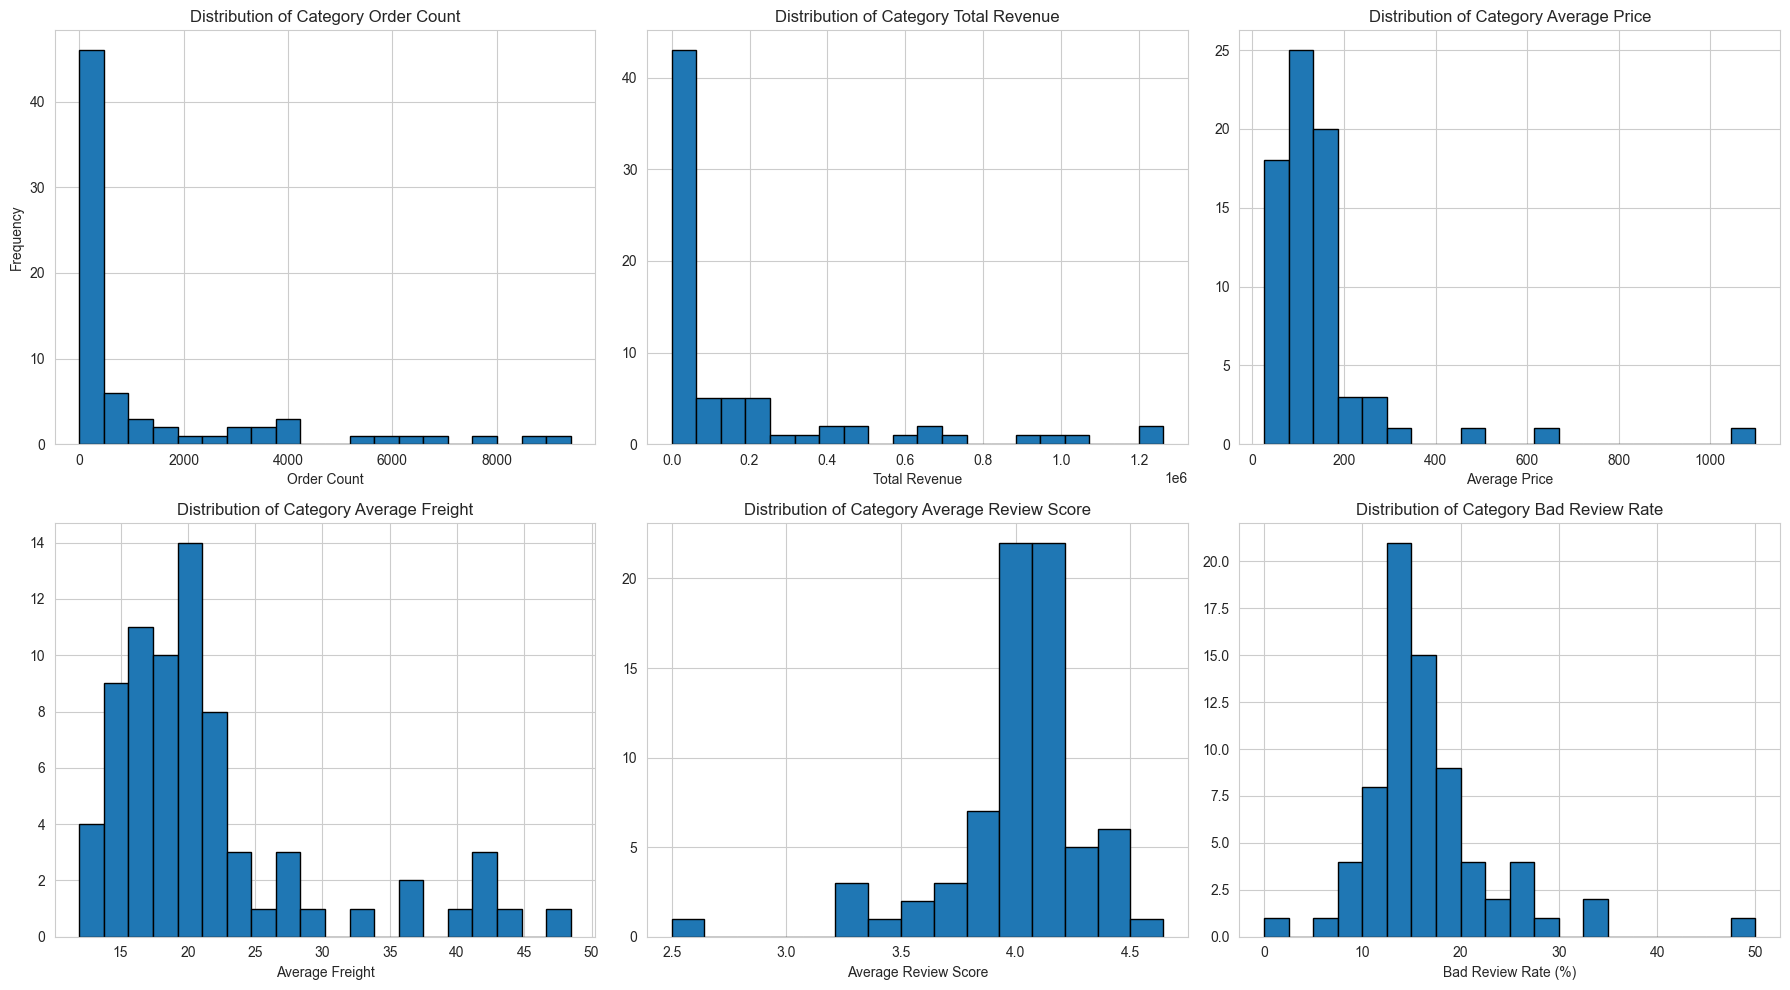

In [12]:
# plot the distribution of major category-level metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# order count
axes[0, 0].hist(df_category["order_count"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of Category Order Count")
axes[0, 0].set_xlabel("Order Count")
axes[0, 0].set_ylabel("Frequency")

# total revenue
axes[0, 1].hist(df_category["total_revenue"], bins=20, edgecolor="black")
axes[0, 1].set_title("Distribution of Category Total Revenue")
axes[0, 1].set_xlabel("Total Revenue")

# average price
axes[0, 2].hist(df_category["avg_price"], bins=20, edgecolor="black")
axes[0, 2].set_title("Distribution of Category Average Price")
axes[0, 2].set_xlabel("Average Price")

# average freight
axes[1, 0].hist(df_category["avg_freight"], bins=20, edgecolor="black")
axes[1, 0].set_title("Distribution of Category Average Freight")
axes[1, 0].set_xlabel("Average Freight")

# average review score
axes[1, 1].hist(df_category["avg_review_score"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of Category Average Review Score")
axes[1, 1].set_xlabel("Average Review Score")

# bad review rate
axes[1, 2].hist(df_category["bad_review_rate"], bins=20, edgecolor="black")
axes[1, 2].set_title("Distribution of Category Bad Review Rate")
axes[1, 2].set_xlabel("Bad Review Rate (%)")

plt.tight_layout()
plt.show()

### Category-level Numerical Distribution Analysis
The distribution plots show that category performance is highly uneven across product categories. Both `order_count` and `total_revenue` are strongly right-skewed, which means a small number of categories contribute a disproportionately large share of total sales and orders. By contrast, `avg_review_score` is much more concentrated, with most categories clustered around 4.0, suggesting that customer satisfaction is relatively stable across categories. `avg_price`, `avg_freight`, and `bad_review_rate` also show noticeable variation, indicating that categories differ not only in sales scale but also in pricing structure, logistics burden, and review risk.

In [13]:
# summary statistics for key category-level variables

summary_stats = df_category[
    [
        "order_count",
        "customer_count",
        "total_revenue",
        "total_gmv",
        "avg_price",
        "avg_freight",
        "avg_review_score",
        "bad_review_rate",
        "avg_comment_len",
        "repeat_rate",
        "category_lifetime_days",
    ]
].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
order_count,73.0,1342.726027,2252.345988,2.000000,75.000000,244.000000,1273.000000,9.417000e+03
customer_count,73.0,1342.726027,2252.345988,2.000000,75.000000,244.000000,1273.000000,9.417000e+03
total_revenue,73.0,184193.989726,301910.559304,283.290000,7528.410000,46328.370000,191498.880000,1.261035e+06
total_gmv,73.0,214750.303288,349566.278958,324.510000,8754.610000,50193.570000,210137.370000,1.444124e+06
avg_price,73.0,146.695252,146.105578,25.342333,81.801667,114.949474,154.407282,1.098341e+03
avg_freight,73.0,21.620984,8.198948,11.938750,16.255090,19.324810,22.724680,4.845468e+01
avg_review_score,73.0,4.019816,0.313812,2.500000,3.936500,4.056200,4.170000,4.642900e+00
bad_review_rate,73.0,16.405375,6.885987,0.000000,12.978280,15.068490,18.000000,5.000000e+01
avg_comment_len,73.0,30.527571,13.073281,4.125000,26.740700,29.305600,32.806700,1.150000e+02
repeat_rate,73.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00


### summary statistics analysis
The descriptive statistics further confirm that category performance is highly dispersed. For example, the median `order_count` is only 244, while the mean is much higher at about 1342.73, showing that a few very large categories pull the average upward. A similar pattern appears in `total_revenue`, where the mean is far above the median, again indicating strong concentration among top-performing categories. In contrast, `avg_review_score` has a narrow spread around 4.02, suggesting that satisfaction differences exist but are much smaller than sales differences. It is also worth noting that `repeat_rate` is constant at 1.0 for all categories, which means this variable has no variation in the current aggregated table and may have limited analytical value in later sections.

### 2.3 Outlier Detection for Key Category Metrics
Because category-level business indicators may be dominated by a few extremely large or small categories, it is useful to check whether outliers are present. Outlier detection helps distinguish between normal variation and unusually extreme category behaviour. In this project, the IQR rule is used as a simple and interpretable method for identifying extreme values.

In [14]:
# function to detect outliers using IQR
def detect_outliers_iqr(df, columns):
    results = []

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

        results.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_pct": outlier_mask.mean() * 100
        })

    return pd.DataFrame(results)

key_vars = ["order_count", "total_revenue", "avg_price", "avg_freight", "bad_review_rate"]

outlier_summary = detect_outliers_iqr(df_category, key_vars)
outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,order_count,75.000000,1273.000000,1198.000000,-1722.000000,3070.000000,13,17.808219
1,total_revenue,7528.410000,191498.880000,183970.470000,-268427.295000,467454.585000,11,15.068493
2,avg_price,81.801667,154.407282,72.605615,-27.106756,263.315705,7,9.589041
3,avg_freight,16.255090,22.724680,6.469590,6.550705,32.429065,9,12.328767
4,bad_review_rate,12.978280,18.000000,5.021720,5.445700,25.532580,9,12.328767


### IQR analysis
The IQR-based outlier summary shows that extreme values are most visible in `order_count` and `total_revenue`, where 13 and 11 categories are flagged as outliers respectively. This suggests that category sales structure is strongly dominated by a relatively small group of very large categories. Outliers are also present in `avg_price`, `avg_freight`, and `bad_review_rate`, although to a lesser extent, indicating that some categories are unusually expensive, costly to deliver, or associated with unusually high negative feedback. These results suggest that outliers in this project are not random noise, but potentially meaningful business signals.

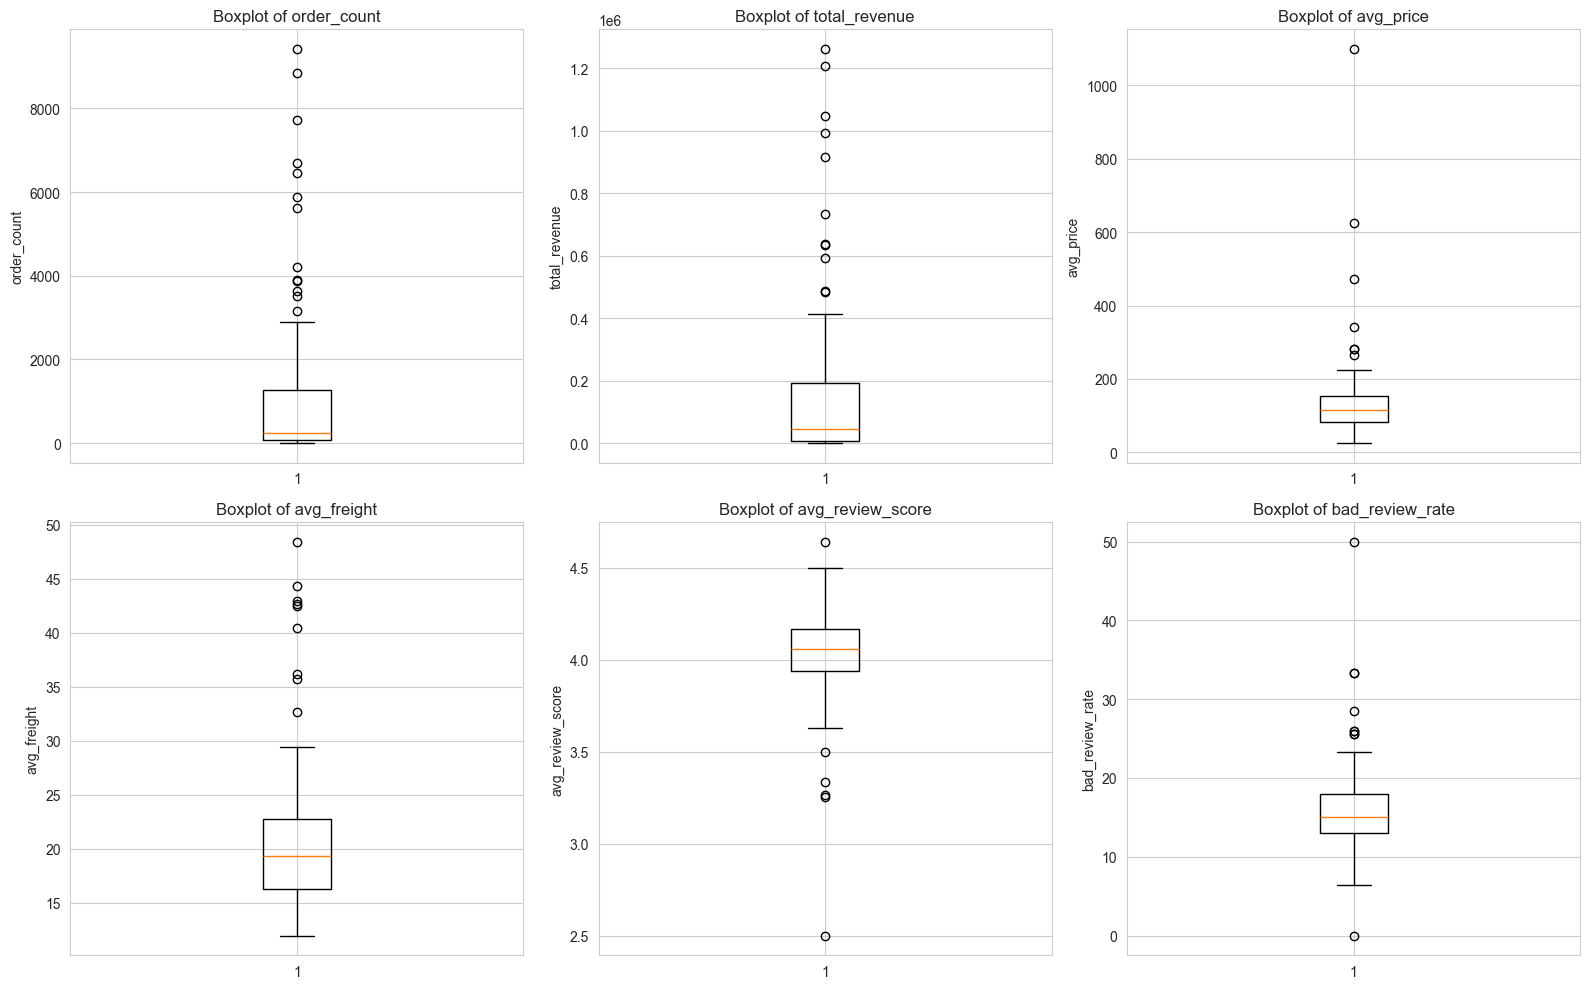

In [15]:
# boxplots for selected category-level variables

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_vars = ["order_count", "total_revenue", "avg_price", "avg_freight", "avg_review_score", "bad_review_rate"]

for i, col in enumerate(plot_vars):
    axes[i].boxplot(df_category[col].dropna(), vert=True)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### boxplots for selected category-level variables analysis
The boxplots provide a visual confirmation of the outlier patterns identified above. `order_count` and `total_revenue` show long upper tails and many points above the upper whisker, which indicates that several categories perform far above the typical range. `avg_price` and `avg_freight` also contain a number of high-end outliers, suggesting that some product groups operate in clearly different price and logistics bands. Meanwhile, `avg_review_score` is much more tightly distributed, although a few low-score categories stand out and many deserve closer business attention. The `bad_review_rate` boxplot also reveals several high-risk categories with unusually poor review outcomes.

In [16]:
# identify the specific categories flagged as outliers for selected variables

for col in ["order_count", "total_revenue", "avg_price", "bad_review_rate"]:
    q1 = df_category[col].quantile(0.25)
    q3 = df_category[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_category[
        (df_category[col] < lower_bound) | (df_category[col] > upper_bound)
    ][["category", col]].sort_values(col, ascending=False)

    print(f"\nOutlier categories for {col}:")
    display(outliers)


Outlier categories for order_count:


,category,order_count
13,cama_mesa_banho,9417
11,beleza_saude,8836
32,esporte_lazer,7720
44,informatica_acessorios,6689
54,moveis_decoracao,6449
72,utilidades_domesticas,5884
66,relogios_presentes,5624
70,telefonia,4199
8,automotivo,3897
12,brinquedos,3886



Outlier categories for total_revenue:


,category,total_revenue
11,beleza_saude,1261034.70
66,relogios_presentes,1206047.43
13,cama_mesa_banho,1045462.93
32,esporte_lazer,991175.20
44,informatica_acessorios,916137.43
54,moveis_decoracao,733077.86
26,cool_stuff,636254.61
72,utilidades_domesticas,632981.59
8,automotivo,593227.66
40,ferramentas_jardim,486400.55



Outlier categories for avg_price:


,category,avg_price
61,pcs,1098.340542
64,portateis_casa_forno_e_cafe,624.285658
29,eletrodomesticos_2,473.272458
0,agro_industria_e_comercio,342.124858
45,instrumentos_musicais,281.616000
31,eletroportateis,280.284112
65,portateis_cozinha_e_preparadores_de_alimentos,264.568667



Outlier categories for bad_review_rate:


,category,bad_review_rate
67,seguros_e_servicos,50.00000
65,portateis_cozinha_e_preparadores_de_alimentos,33.33333
60,pc_gamer,33.33333
38,fashion_roupa_masculina,28.46154
15,casa_conforto_2,25.92593
55,moveis_escritorio,25.92372
42,fraldas_higiene,25.64103
71,telefonia_fixa,25.57252
17,cds_dvds_musicais,0.00000


### The category-level outlier tables analysis
The category-level outlier tables show that the extreme observations are concentrated in a few specific product groups. In terms of sales scale, categories such as `cama_mesa_banho`, `beleza_saude`, `esporte_lazer`, `informatica_acessorios`, and `moveis_decoracao` stand out as major outliers in both `order_count` and `total_revenue`, which suggests that they function as core commercial categories in the platform. In terms of pricing, categories such as `pcs`, `portateis_casa_forno_e_cafe`, and `eletrodomesticos_2` have exceptionally high average prices, indicating that they belong to premium or specialised product segments rather than mass-market categories. In contrast, categories such as `seguros_e_servicos`, `pc_gamer`, and `fashion_roupa_masculina` appear as outliers in `bad_review_rate`, suggesting potential issues in customer expectation, product quality, or service performance. Overall, these outlier categories should not be treated as data errors; instead, they represent strategically important groups that deserve closer examination in the later ranking and business insight sections.

### 2.4 Preliminary Revenue Concentration Check
Before moving to formal ranking analysis, it is useful to briefly examine how concentrated category revenue is. This provides an early indication of whether the category structure is broad-based or heavily dependent on a small number of categories.

In [17]:
# calculate category revenue share
df_concentration = df_category[["category", "total_revenue"]].copy()
df_concentration["revenue_share_pct"] = (
    df_concentration["total_revenue"] / df_concentration["total_revenue"].sum() * 100
)

df_concentration = df_concentration.sort_values("total_revenue", ascending=False)

print("Top 10 categories by revenue share:")
display(df_concentration.head(10))

print(f"Revenue share of top 5 categories: {df_concentration.head(5)['revenue_share_pct'].sum():.2f}%")
print(f"Revenue share of top 10 categories: {df_concentration.head(10)['revenue_share_pct'].sum():.2f}%")

Top 10 categories by revenue share:


,category,total_revenue,revenue_share_pct
11,beleza_saude,1261034.70,9.378399
66,relogios_presentes,1206047.43,8.969455
13,cama_mesa_banho,1045462.93,7.775178
32,esporte_lazer,991175.20,7.371436
44,informatica_acessorios,916137.43,6.813375
54,moveis_decoracao,733077.86,5.451949
26,cool_stuff,636254.61,4.731868
72,utilidades_domesticas,632981.59,4.707526
8,automotivo,593227.66,4.411874
40,ferramentas_jardim,486400.55,3.617393


Revenue share of top 5 categories: 40.31%
Revenue share of top 10 categories: 63.23%


### Top 10 categories by revenue share analysis
The preliminary revenue concentration results show that category sales are highly concentrated among a small number of leading categories. `beleza_saude` ranks first, contributing about 9.38% of total revenue alone, followed by `relogios_presentes` at 8.97% and `cama_mesa_banho` at 7.78%. More importantly, the top 5 categories together account for 40.31% of total revenue, while the top 10 categories contribute 63.23%. This indicates that the platform’s category revenue structure is strongly dependent on a relatively limited set of core categories, which is an important business signal for later Pareto analysis and category strategy planning.

## 3. Category Ranking Analysis
Category ranking analysis aims to identify the best-performing and worst-performing product categories from multiple business perspectives. Instead of looking at only one metric, this chapter compares categories by revenue, order volume, customer satisfaction, and bad review rate. This helps distinguish categories that are commercially important from those that many require operational attention. Such ranking analysis also provides the basis for later Parato analysis and BCG-style strategic classification.

### 3.1 Top 10 Categories by Revenue analysis
Revenue is one of the most direct indicators of category business value. Analysing the top categories by total revenue helps identify which product groups contribute most strongly to platform income. These categories are commercially important because they often represent the main drivers of gross merchandise performance and should therefore receive closer attention in later strategic analysis.

In [18]:
# rank categories by total revenue

top10_revenue = (
    df_category[["category", "total_revenue", "order_count", "avg_review_score"]]
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

print("Top 10 categories by total revenue")
display(top10_revenue)

Top 10 categories by total revenue


,category,total_revenue,order_count,avg_review_score
11,beleza_saude,1261034.70,8836,4.1422
66,relogios_presentes,1206047.43,5624,4.0192
13,cama_mesa_banho,1045462.93,9417,3.9022
32,esporte_lazer,991175.20,7720,4.1087
44,informatica_acessorios,916137.43,6689,3.9364
54,moveis_decoracao,733077.86,6449,3.9114
26,cool_stuff,636254.61,3632,4.1480
72,utilidades_domesticas,632981.59,5884,4.0562
8,automotivo,593227.66,3897,4.0650
40,ferramentas_jardim,486400.55,3518,4.0435


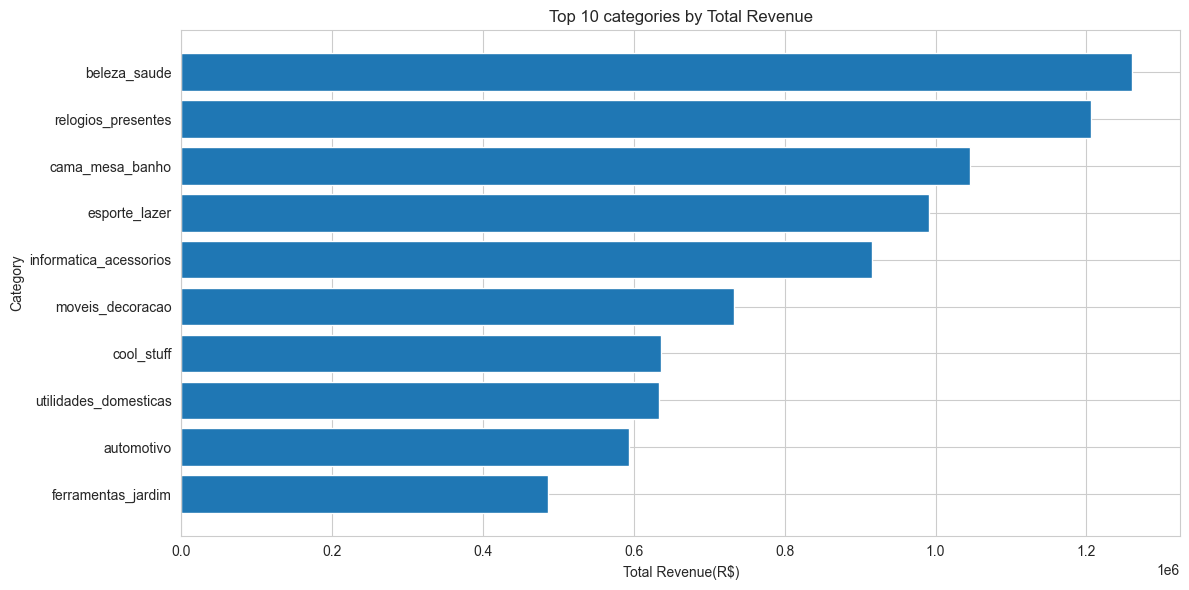

In [19]:
# visualise top 10 categories by total revenue

plt.figure(figsize=(12, 6))
plt.barh(top10_revenue["category"], top10_revenue["total_revenue"])
plt.xlabel("Total Revenue(R$)")
plt.ylabel("Category")
plt.title("Top 10 categories by Total Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# add revenue share for easier interpretation

top10_revenue = top10_revenue.copy()
top10_revenue["revenue_share_pct"] = (
    top10_revenue["total_revenue"] / df_category["total_revenue"].sum() * 100
)

display(top10_revenue)

,category,total_revenue,order_count,avg_review_score,revenue_share_pct
11,beleza_saude,1261034.70,8836,4.1422,9.378399
66,relogios_presentes,1206047.43,5624,4.0192,8.969455
13,cama_mesa_banho,1045462.93,9417,3.9022,7.775178
32,esporte_lazer,991175.20,7720,4.1087,7.371436
44,informatica_acessorios,916137.43,6689,3.9364,6.813375
54,moveis_decoracao,733077.86,6449,3.9114,5.451949
26,cool_stuff,636254.61,3632,4.1480,4.731868
72,utilidades_domesticas,632981.59,5884,4.0562,4.707526
8,automotivo,593227.66,3897,4.0650,4.411874
40,ferramentas_jardim,486400.55,3518,4.0435,3.617393


### Top 10 Categories by Revenue analysis
The revenue ranking shows that platform income is concentrated in a relatively small group of categories. **beleza_saude** ranks first with total revenue of **R1,261,034.70**, followed by **relogios_presentes** at **R1,206,047.43** and **cama_mesa_banho** at **R1,045,462.93**. Together, these categories form the core revenue drivers of the platform.

Most of the top revenue categories also have high order volumes, such as **beleza_saude**, **cama_mesa_banho**, and **esporte_lazer**, which suggests that their revenue strength is supported by broad market demand rather than only high unit prices. However, some high-revenue categories, including **cama_mesa_banho**, **informatica_acessorios**, and **moveis_decoracao**, have only moderate average review scores. This suggests that strong sales performance does not always correspond to the best customer experience, and these categories deserve further attention in later satisfaction analysis.

### 3.2 Top 10 Categories by Order Count
Order count reflects how frequently a category is purchased and is important indicator of category popularity and market demand. While revenue highlights business value, order volume reveals how broad the demand base is. Analysing the top categories by order count helps identify the most frequently purchased product groups and allow comparison with the revenue ranking above.

In [21]:
# rank categories by order count

top10_orders = (
    df_category[["category", "order_count", "total_revenue", "avg_review_score"]]
    .sort_values("order_count", ascending=False)
    .head(10)
)

print("Top 10 categories by order count")
display(top10_orders)

Top 10 categories by order count


,category,order_count,total_revenue,avg_review_score
13,cama_mesa_banho,9417,1045462.93,3.9022
11,beleza_saude,8836,1261034.70,4.1422
32,esporte_lazer,7720,991175.20,4.1087
44,informatica_acessorios,6689,916137.43,3.9364
54,moveis_decoracao,6449,733077.86,3.9114
72,utilidades_domesticas,5884,632981.59,4.0562
66,relogios_presentes,5624,1206047.43,4.0192
70,telefonia,4199,323735.40,3.9472
8,automotivo,3897,593227.66,4.0650
12,brinquedos,3886,484090.30,4.1617


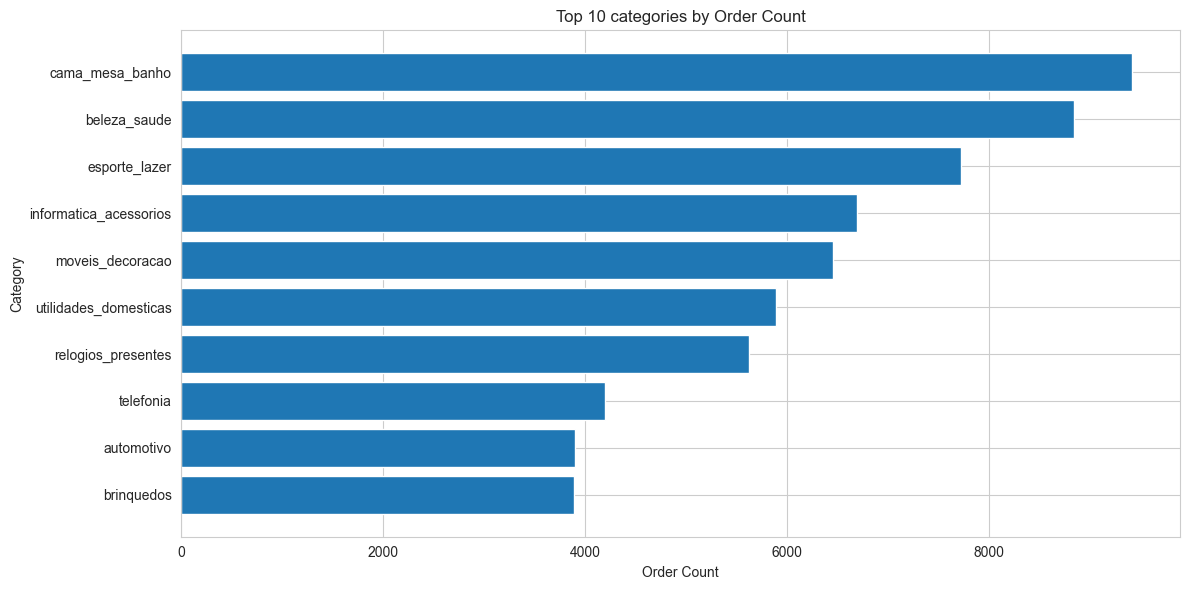

In [22]:
# visualise top 10 categories by order count

plt.figure(figsize=(12, 6))
plt.barh(top10_orders["category"], top10_orders["order_count"])
plt.xlabel("Order Count")
plt.ylabel("Category")
plt.title("Top 10 categories by Order Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# add order share for easier interpretation

top10_orders = top10_orders.copy()
top10_orders["order_share_pct"] = (
    top10_orders["order_count"] / df_category["order_count"].sum() * 100
)

display(top10_orders)

,category,order_count,total_revenue,avg_review_score,order_share_pct
13,cama_mesa_banho,9417,1045462.93,3.9022,9.607321
11,beleza_saude,8836,1261034.70,4.1422,9.014579
32,esporte_lazer,7720,991175.20,4.1087,7.876024
44,informatica_acessorios,6689,916137.43,3.9364,6.824187
54,moveis_decoracao,6449,733077.86,3.9114,6.579337
72,utilidades_domesticas,5884,632981.59,4.0562,6.002918
66,relogios_presentes,5624,1206047.43,4.0192,5.737663
70,telefonia,4199,323735.40,3.9472,4.283863
8,automotivo,3897,593227.66,4.0650,3.975760
12,brinquedos,3886,484090.30,4.1617,3.964537


### 3.2 Top 10 Categories by Order Count Analysis
The order-count ranking highlights the categories with the broadest and most frequent customer demand. **cama_mesa_banho** ranks first with **9,417 orders**, followed by **beleza_saude** with **8,836 orders** and **esporte_lazer** with **7,720 orders**. These categories can be seen as major traffic-driving groups on the platform.

There is strong overlap between the top categories by revenue and by order count, which indicates that the platform’s core commercial categories are also its most frequently purchased ones. At the same time, some categories show a difference between revenue rank and order-volume rank. For example, **relogios_presentes** generates very high revenue with fewer orders than **cama_mesa_banho** or **beleza_saude**, suggesting a stronger contribution from higher average product value. In contrast, categories such as **telefonia** and **brinquedos** enter the top 10 by order volume but not by revenue, which may indicate relatively lower average transaction value.

### 3.3 Top 10 Categories by Satisfaction
Average review score is used to evaluate category-level customer satisfaction. However, categories with very few orders may show unstable average scores due to limited observations. Therefore, a minimum order threshold is applied before ranking categories by satisfaction, so that the comparison is more reliable and meaningful.

In [24]:
### 3.3 Top 10 Categories with enough order volume
min_orders = 100

df_satisfaction_rank = df_category[df_category["order_count"] >= min_orders].copy()

top10_satisfaction = (
    df_satisfaction_rank[["category", "avg_review_score", "order_count", "total_revenue"]]
    .sort_values("avg_review_score", ascending=False)
    .head(10)
)

print(f"Top 10 categories by satisfaction (min {min_orders} orders)")
display(top10_satisfaction)

Top 10 categories by satisfaction (min 100 orders)


,category,avg_review_score,order_count,total_revenue
48,livros_interesse_geral,4.4453,512,46856.88
49,livros_tecnicos,4.3684,260,19149.03
50,malas_acessorios,4.3153,1034,140429.98
2,alimentos_bebidas,4.3091,227,15218.47
34,fashion_calcados,4.2374,240,23592.67
1,alimentos,4.2134,450,29393.41
59,papelaria,4.1959,2311,231139.23
63,pet_shop,4.1841,1710,214443.41
61,pcs,4.1750,181,222963.13
28,eletrodomesticos,4.1700,764,82349.27


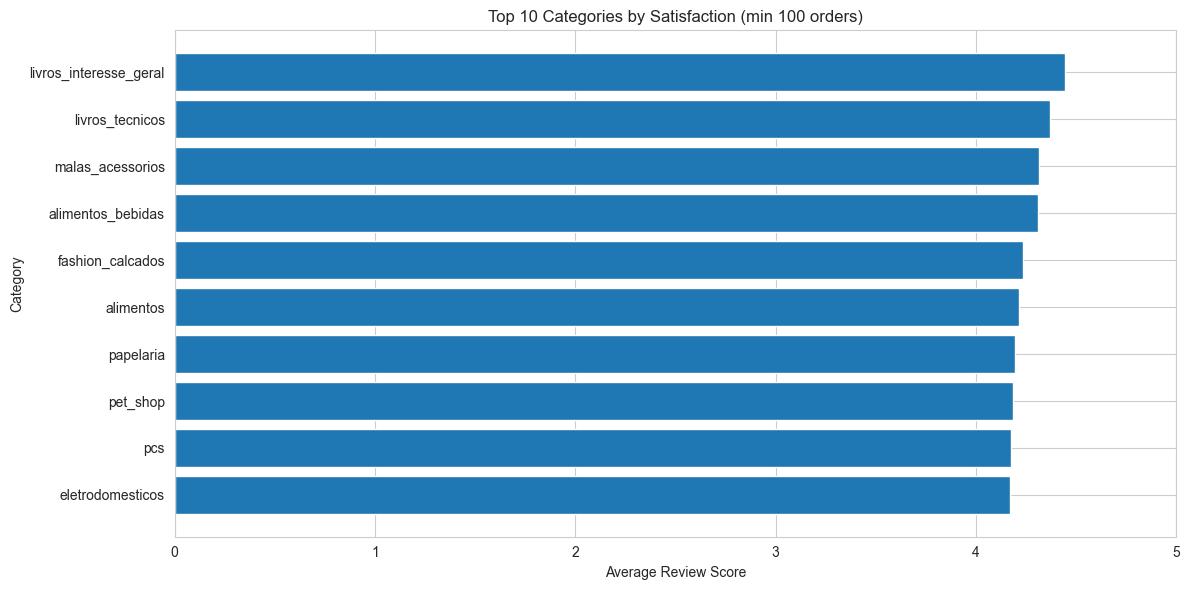

In [25]:
# visualise top 10 categories by satisfaction

plt.figure(figsize=(12, 6))
plt.barh(top10_satisfaction["category"], top10_satisfaction["avg_review_score"])
plt.xlabel("Average Review Score")
plt.ylabel("Category")
plt.title(f"Top 10 Categories by Satisfaction (min {min_orders} orders)")
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top 10 Categories by Satisfaction Analysis

The satisfaction ranking shows that the highest-rated categories are not necessarily the largest revenue contributors. **livros_interesse_geral** ranks first with an average review score of **4.4453**, followed by **livros_tecnicos** at **4.3684** and **malas_acessorios** at **4.3153**. These categories perform strongly in customer evaluation, suggesting that they provide a relatively positive purchase experience.

However, most of the top satisfaction categories have only moderate or relatively low order volumes and revenue compared with the platform’s leading commercial categories. For example, although **pcs** has a high average score, its order volume is only **181**, while categories such as **papelaria** and **pet_shop** combine stronger customer satisfaction with broader market demand. This suggests that high satisfaction alone does not automatically translate into large-scale commercial performance. Therefore, these categories may represent well-performing but under-scaled opportunities that deserve further attention in later strategy analysis.

### 3.4 Categories with Highest Bad Review Rate
Bad review rate reflects the proportion of strongly negative customer feedback within each category. Compared with average review score, this metric is more sensitive to dissatisfaction risk and can help identify-categories that may require operational improvement. Tp reduce instability caused by very small sample sizes, the same minimum order threshold is used here.

In [26]:
# rank categories by bad review rate
top10_bad_review = (
    df_satisfaction_rank[["category", "bad_review_rate", "avg_review_score", "order_count"]]
    .sort_values("bad_review_rate", ascending=False)
    .head(10)
)

print(f"Top 10 categories by bad review rate (min {min_orders} orders)")
display(top10_bad_review)

Top 10 categories by bad review rate (min 100 orders)


,category,bad_review_rate,avg_review_score,order_count
38,fashion_roupa_masculina,28.46154,3.6385,112
55,moveis_escritorio,25.92372,3.4988,1273
71,telefonia_fixa,25.57252,3.6832,217
7,audio,21.66667,3.8333,350
14,casa_conforto,20.32333,3.8291,397
25,construcao_ferramentas_seguranca,20.20725,3.8446,167
54,moveis_decoracao,19.30403,3.9114,6449
13,cama_mesa_banho,18.75570,3.9022,9417
44,informatica_acessorios,18.44209,3.9364,6689
57,moveis_sala,18.34677,3.8931,422


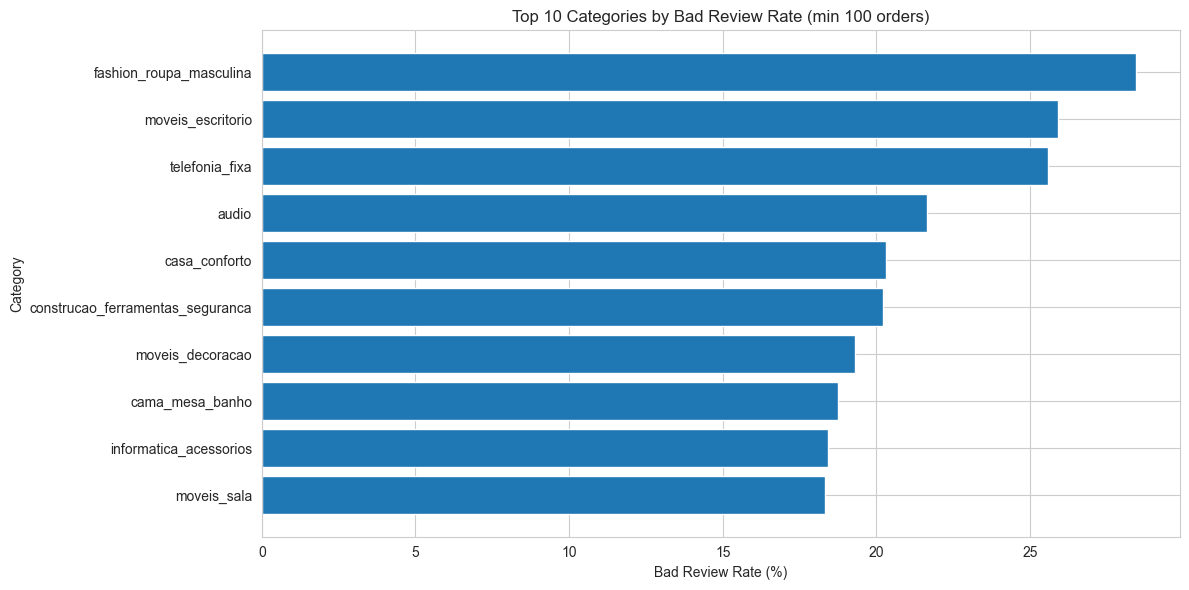

In [27]:
# visualise categories with highest bad review rate

plt.figure(figsize=(12, 6))
plt.barh(top10_bad_review["category"], top10_bad_review["bad_review_rate"])
plt.xlabel("Bad Review Rate (%)")
plt.ylabel("Category")
plt.title(f"Top 10 Categories by Bad Review Rate (min {min_orders} orders)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Categories with Highest Bad Review Rate Analysis
The bad review rate ranking highlights the categories with the greatest dissatisfaction risk. `fashion_roupa_masculina` ranks first, with a bad review rate of **28.46%**, followed by `moveis_escritorio` at **25.92%** and `telefonia_fixa` at **25.57%**. These categories show a relatively high concentration of strongly negative feedback and may require closer operational attention.

Compared with the satisfaction ranking above, the bad review ranking provides a more risk-focused perspective. Some categories with high bad review rates, such as `moveis_decoracao`, `cama_mesa_banho`, and `informatica_acessorios`, also have very large order volumes. This is particularly important because dissatisfaction in these categories affects not only customer experience but also a substantial share of platform transactions. Therefore, these categories should be treated as priority areas for further investigation, especially in terms of product quality, delivery performance, and expectation management.

### 3.5 Pareto Analysis of Category Revenue

To further evaluate category revenue concentration, Pareto analysis is applied to examine how much of the total revenue is contributed by the leading categories. This helps identify the core categories that account for most of the platform’s revenue and provides support for category prioritisation and inventory planning.

In [28]:
# prepare pareto analysis table
df_pareto = df_category[["category", "total_revenue"]].copy()
df_pareto = df_pareto.sort_values("total_revenue", ascending=False)

df_pareto["cumulative_revenue"] = df_pareto["total_revenue"].cumsum()
df_pareto["cumulative_pct"] = (
    df_pareto["cumulative_revenue"] / df_pareto["total_revenue"].sum() * 100
)

display(df_pareto.head(15))

,category,total_revenue,cumulative_revenue,cumulative_pct
11,beleza_saude,1261034.70,1261034.70,9.378399
66,relogios_presentes,1206047.43,2467082.13,18.347855
13,cama_mesa_banho,1045462.93,3512545.06,26.123032
32,esporte_lazer,991175.20,4503720.26,33.494469
44,informatica_acessorios,916137.43,5419857.69,40.307844
54,moveis_decoracao,733077.86,6152935.55,45.759793
26,cool_stuff,636254.61,6789190.16,50.491661
72,utilidades_domesticas,632981.59,7422171.75,55.199187
8,automotivo,593227.66,8015399.41,59.611061
40,ferramentas_jardim,486400.55,8501799.96,63.228455


In [29]:
# identify core categories contributing to about 80% of revenue
core_categories = df_pareto[df_pareto["cumulative_pct"] <= 80].copy()

print("Number of core categories contributing around 80% revenue:")
print(core_categories.shape[0])

display(core_categories)

Number of core categories contributing around 80% revenue:
16


,category,total_revenue,cumulative_revenue,cumulative_pct
11,beleza_saude,1261034.70,1261034.70,9.378399
66,relogios_presentes,1206047.43,2467082.13,18.347855
13,cama_mesa_banho,1045462.93,3512545.06,26.123032
32,esporte_lazer,991175.20,4503720.26,33.494469
44,informatica_acessorios,916137.43,5419857.69,40.307844
54,moveis_decoracao,733077.86,6152935.55,45.759793
26,cool_stuff,636254.61,6789190.16,50.491661
72,utilidades_domesticas,632981.59,7422171.75,55.199187
8,automotivo,593227.66,8015399.41,59.611061
40,ferramentas_jardim,486400.55,8501799.96,63.228455


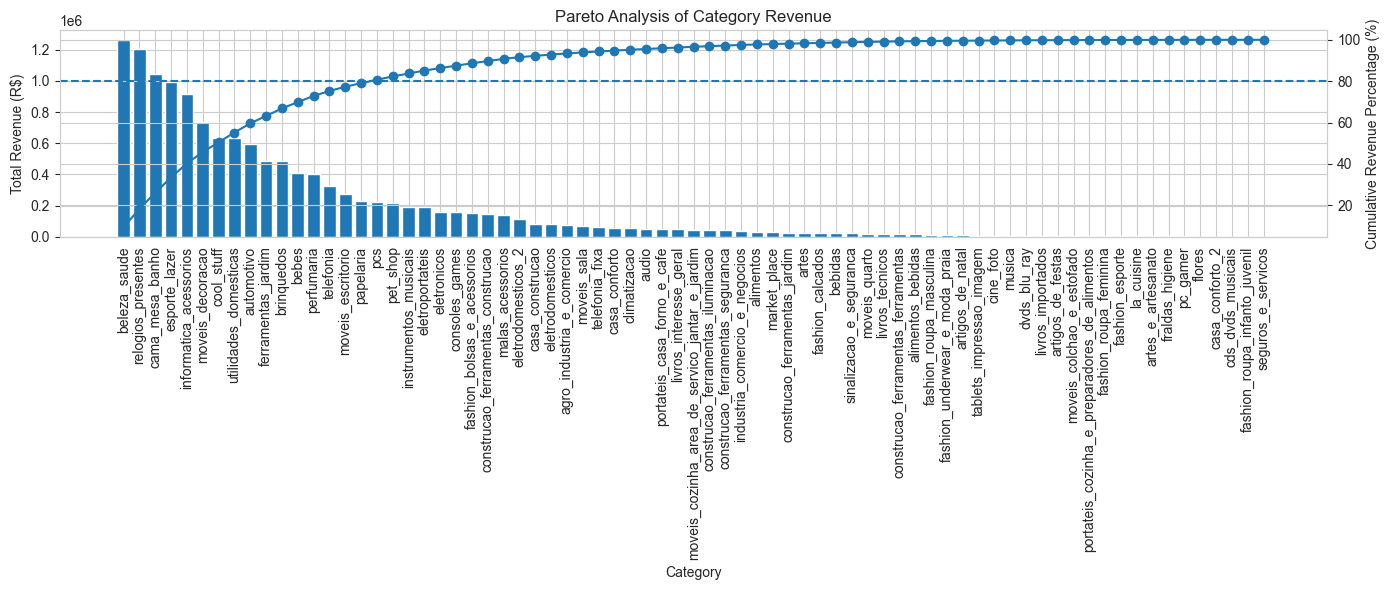

In [30]:
# pareto chart
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(df_pareto["category"], df_pareto["total_revenue"])
ax1.set_xlabel("Category")
ax1.set_ylabel("Total Revenue (R$)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(df_pareto["category"], df_pareto["cumulative_pct"], marker="o")
ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Cumulative Revenue Percentage (%)")

plt.title("Pareto Analysis of Category Revenue")
plt.tight_layout()
plt.show()

### Pareto Analysis of Category Revenue Analysis
The Pareto analysis shows that category revenue is highly concentrated. A total of **16 categories** account for around **80%** of the platform’s total revenue, which means that only a relatively small share of categories contributes most of the commercial value. This confirms that the platform has a strong revenue concentration structure rather than an evenly distributed category portfolio.

The core revenue categories include `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios`, all of which make substantial cumulative contributions to total revenue. As the cumulative curve rises quickly in the early part of the chart and then gradually flattens, it becomes clear that the platform depends heavily on a limited set of leading categories. From a business perspective, these core categories should be treated as strategic priorities in category management, inventory allocation, and promotional planning.

## 4. BCG Matrix Analysis

After comparing category performance from multiple ranking perspectives, the next step is to move from descriptive comparison to strategic classification. In this section, a BCG-style matrix is used to group categories based on their commercial value and customer satisfaction. This helps distinguish high-performing categories from risky or underdeveloped ones and provides a clearer basis for later business recommendations.

### 4.1 Defining the BCG Matrix Framework

To move from simple ranking analysis to strategic category classification, a BCG-style matrix is introduced. In this project, **total revenue** is used to represent category business scale, while **average review score** is used to reflect customer satisfaction and growth potential. By combining these two dimensions, categories can be grouped into four strategic types: high-revenue and high-satisfaction categories, high-revenue but low-satisfaction categories, low-revenue but high-satisfaction categories, and low-revenue and low-satisfaction categories.

To make the classification simple and interpretable, the median values of `total_revenue` and `avg_review_score` are used as the dividing lines. This allows each category to be assigned into one of four groups for later business interpretation.

In [31]:
# calculate median thresholds for BCG-style classification

median_revenue = df_category["total_revenue"].median()
median_score = df_category["avg_review_score"].median()

print(f"Median total revenue: {median_revenue:.2f}")
print(f"Median average review score: {median_score:.4f}")

Median total revenue: 46328.37
Median average review score: 4.0562


In [32]:
# classify categories into four BCG-style groups

def classify_bcg_category(row):
    if row["total_revenue"] >= median_revenue and row["avg_review_score"] >= median_score:
        return "Star"
    elif row["total_revenue"] >= median_revenue and row["avg_review_score"] < median_score:
        return "Problem"
    elif row["total_revenue"] < median_revenue and row["avg_review_score"] >= median_score:
        return "Opportunity"
    else:
        return "Dog"

df_category["bcg_category"] = df_category.apply(classify_bcg_category, axis=1)

print("BCG category counts:")
display(df_category["bcg_category"].value_counts())

BCG category counts:


bcg_category
Star           19
Problem        18
Opportunity    18
Dog            18
Name: count, dtype: int64

### Analysis
The median thresholds used for the BCG-style classification are **R$46,328.37** for `total_revenue` and **4.0562** for `avg_review_score`. These two values provide a simple and interpretable benchmark for separating categories into above-median and below-median groups in terms of both commercial scale and customer satisfaction.

The classification results are highly balanced, with **19** categories assigned to `Star` and **18** categories each assigned to `Problem`, `Opportunity`, and `Dog`. This balanced distribution is expected because median values are used as the dividing lines. It also suggests that the category portfolio can be meaningfully separated into four strategic groups, which provides a useful foundation for the visual matrix analysis in the next section.

### 4.2 BCG Matrix Visualisation

After defining the four BCG-style groups, the next step is to visualise the category portfolio in a two-dimensional matrix. In this chart, `total_revenue` is plotted on the horizontal axis and `avg_review_score` on the vertical axis. The size of each point represents `order_count`, which allows the matrix to reflect not only category position but also transaction scale.

The vertical and horizontal reference lines are set at the median values of `total_revenue` and `avg_review_score`, dividing the chart into four quadrants. This makes it easier to identify which categories belong to `Star`, `Problem`, `Opportunity`, and `Dog`, and to compare their relative scale and satisfaction performance.

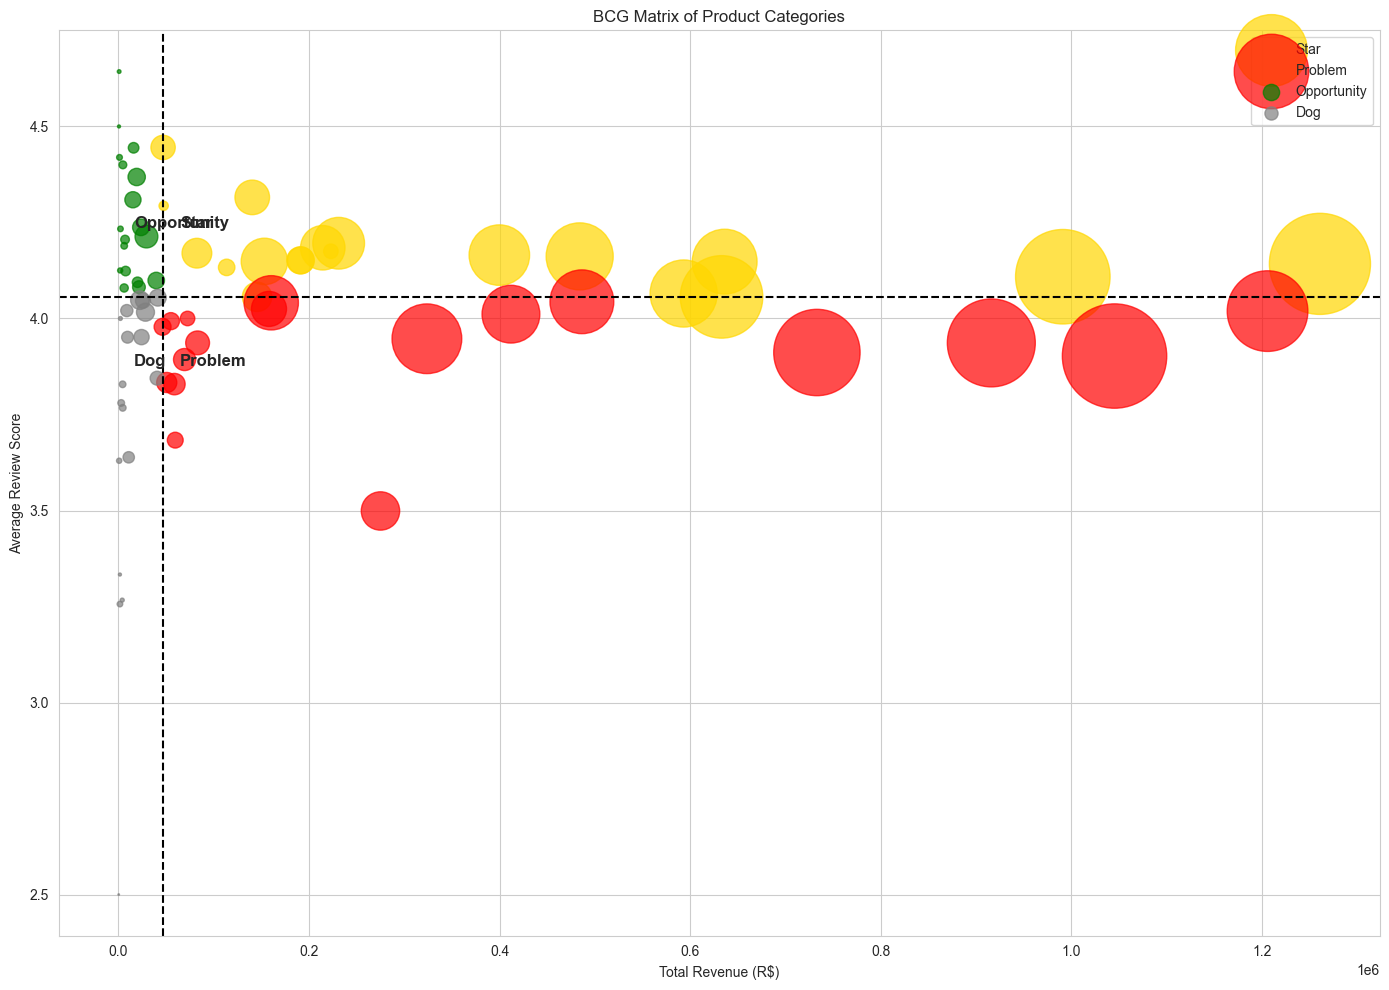

In [33]:
# visualise categories in a BCG-style matrix

plt.figure(figsize=(14, 10))

colors = {
    "Star": "gold",
    "Problem": "red",
    "Opportunity": "green",
    "Dog": "gray"
}

for group, color in colors.items():
    subset = df_category[df_category["bcg_category"] == group]
    plt.scatter(
        subset["total_revenue"],
        subset["avg_review_score"],
        s=subset["order_count"] * 0.6,
        alpha=0.7,
        label=group,
        c=color
    )

# add median reference lines
plt.axvline(median_revenue, color="black", linestyle="--", linewidth=1.5)
plt.axhline(median_score, color="black", linestyle="--", linewidth=1.5)

# axis labels and title
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Average Review Score")
plt.title("BCG Matrix of Product Categories")

# optional quadrant labels
plt.text(median_revenue * 1.4, median_score + 0.18, "Star", fontsize=12, weight="bold")
plt.text(median_revenue * 1.4, median_score - 0.18, "Problem", fontsize=12, weight="bold")
plt.text(median_revenue * 0.35, median_score + 0.18, "Opportunity", fontsize=12, weight="bold")
plt.text(median_revenue * 0.35, median_score - 0.18, "Dog", fontsize=12, weight="bold")

plt.legend()
plt.tight_layout()
plt.show()

### BCG Matrix Visualisation Analysis

The BCG matrix shows a clear separation between commercially strong categories and smaller long-tail categories. Most of the large bubbles are concentrated on the right-hand side of the chart, indicating that a relatively small number of categories account for a substantial share of total revenue. At the same time, these high-revenue categories are split across both the upper-right and lower-right quadrants, which suggests that strong commercial performance does not always come with equally strong customer satisfaction.

Several important categories, such as `beleza_saude`, `esporte_lazer`, `cool_stuff`, and `automotivo`, appear in the `Star` quadrant, meaning that they combine above-median revenue with above-median review scores. These categories can be regarded as the strongest parts of the current category portfolio. In contrast, categories such as `cama_mesa_banho`, `moveis_decoracao`, and `informatica_acessorios` fall into the `Problem` quadrant, showing that some of the platform’s major revenue contributors still face below-median satisfaction performance. This makes them strategically important but also operationally risky.

On the left-hand side of the matrix, the `Opportunity` and `Dog` categories are generally much smaller in scale. `Opportunity` categories show relatively good customer satisfaction but limited revenue contribution, suggesting potential for further development. By contrast, `Dog` categories remain weak in both revenue and satisfaction, which means they are less likely to be priority areas unless they have special strategic value.

### 4.3 Category Details by BCG Group

After classifying categories into four BCG-style groups, the next step is to examine the specific categories within each group. This helps identify which categories are strong performers, risky core categories, potential growth categories, and weak categories.

In [34]:
# view category details by BCG group

star_categories = (
    df_category[df_category["bcg_category"] == "Star"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("total_revenue", ascending=False)
)

problem_categories = (
    df_category[df_category["bcg_category"] == "Problem"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("total_revenue", ascending=False)
)

opportunity_categories = (
    df_category[df_category["bcg_category"] == "Opportunity"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("avg_review_score", ascending=False)
)

dog_categories = (
    df_category[df_category["bcg_category"] == "Dog"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("total_revenue", ascending=False)
)

In [35]:
print("Star categories:")
display(star_categories.head(10))

print("Problem categories:")
display(problem_categories.head(10))

print("Opportunity categories:")
display(opportunity_categories.head(10))

print("Dog categories:")
display(dog_categories.head(10))

Star categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
11,beleza_saude,1261034.70,4.1422,8836,13.71381
32,esporte_lazer,991175.20,4.1087,7720,14.55778
26,cool_stuff,636254.61,4.1480,3632,13.07120
72,utilidades_domesticas,632981.59,4.0562,5884,15.61731
8,automotivo,593227.66,4.0650,3897,15.24128
12,brinquedos,484090.30,4.1617,3886,13.44311
62,perfumaria,399772.51,4.1650,3162,14.50382
59,papelaria,231139.23,4.1959,2311,13.02083
61,pcs,222963.13,4.1750,181,13.00000
63,pet_shop,214443.41,4.1841,1710,12.97828


Problem categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
66,relogios_presentes,1206047.43,4.0192,5624,16.25126
13,cama_mesa_banho,1045462.93,3.9022,9417,18.75570
44,informatica_acessorios,916137.43,3.9364,6689,18.44209
54,moveis_decoracao,733077.86,3.9114,6449,19.30403
40,ferramentas_jardim,486400.55,4.0435,3518,16.05281
9,bebes,411942.58,4.0112,2885,16.74893
70,telefonia,323735.40,3.9472,4199,16.82927
55,moveis_escritorio,275014.50,3.4988,1273,25.92372
30,eletronicos,160376.64,4.0408,2550,15.67055
20,consoles_games,158000.22,4.0249,1062,15.30249


Opportunity categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
17,cds_dvds_musicais,730.00,4.6429,12,0.00000
37,fashion_roupa_infanto_juvenil,569.85,4.5000,8,12.50000
22,construcao_ferramentas_ferramentas,15903.95,4.4444,97,8.08081
41,flores,1110.04,4.4194,29,6.45161
47,livros_importados,4639.85,4.4000,53,11.66667
49,livros_tecnicos,19149.03,4.3684,260,10.90226
2,alimentos_bebidas,15218.47,4.3091,227,8.00000
34,fashion_calcados,23592.67,4.2374,240,12.06226
35,fashion_esporte,2119.51,4.2333,27,10.00000
1,alimentos,29393.41,4.2134,450,13.00813


Dog categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
23,construcao_ferramentas_iluminacao,41308.00,4.0541,244,14.52703
25,construcao_ferramentas_seguranca,40544.52,3.8446,167,20.20725
51,market_place,28378.47,4.0163,280,14.33225
24,construcao_ferramentas_jardim,25740.29,4.0462,194,17.64706
3,artes,24202.64,3.9515,202,17.96117
10,bebidas,22505.90,4.0477,297,14.58886
38,fashion_roupa_masculina,10797.82,3.6385,112,28.46154
39,fashion_underwear_e_moda_praia,9541.55,3.9512,121,17.88618
6,artigos_de_natal,8800.82,4.0205,128,14.38356
5,artigos_de_festas,4485.18,3.7674,39,23.25581


### Category Details by BCG Group Analysis
The `Star` group contains the platform’s strongest categories, including `beleza_saude`, `esporte_lazer`, `cool_stuff`, and `automotivo`, which combine high revenue with above-median satisfaction. These categories represent the most balanced and commercially attractive part of the category portfolio.

The `Problem` group includes several major revenue drivers, such as `relogios_presentes`, `cama_mesa_banho`, `informatica_acessorios`, and `moveis_decoracao`, but their review scores remain below the median. This suggests that some core categories generate strong sales while still facing noticeable customer experience risk.

The `Opportunity` group shows relatively high satisfaction but limited revenue contribution. Categories such as `livros_tecnicos`, `alimentos_bebidas`, `fashion_calcados`, and `alimentos` may have growth potential, although some very small categories in this group should be interpreted with caution due to limited order volume. By contrast, the `Dog` group remains weak in both revenue and satisfaction, with categories such as `fashion_roupa_masculina` and `artigos_de_festas` showing relatively limited business strength.

## 5. Customer Preference Analysis by RFM Segment

After classifying product categories by overall performance, the next step is to examine customer preference differences across user segments. By linking category purchases with RFM groups, this section explores whether different customer types show different category preferences and spending patterns.

### 5.1 Loading RFM Segmentation Results

To analyse category preference by customer type, the RFM segmentation results from the previous project are introduced. These results allow the order-level category data to be connected with user groups, providing a foundation for comparing category demand across different segments.

In [36]:
# load RFM segmentation result from the previous project

df_rfm = pd.read_csv("../output/user_segments_rfm.csv")

print(df_rfm.shape)
df_rfm.head()

(95539, 14)


,unique_user_id,cluster,segment,recency,frequency,monetary,R_score,F_score,M_score,RFM_score_simple,RFM_score_weighted,is_repeat_customer,is_churned,strategy
0,0000366f3b9a7992bf8c76cfdf3221e2,1,Recent Single-Purchase Users,2852,1,141.90,4,1,4,9,3.7,0,0,VIP Retention
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,Recent Single-Purchase Users,2855,1,27.19,4,1,1,6,2.2,0,0,Potential Nurturing
2,0000f46a3911fa3c0805444483337064,0,Lapsed Single-Purchase Users,3278,1,86.22,1,1,2,4,1.5,0,1,Low Priority
3,0000f6ccb0745a6a4b88665a16c9f078,0,Lapsed Single-Purchase Users,3062,1,43.62,2,1,1,4,1.4,0,0,Low Priority
4,0004aac84e0df4da2b147fca70cf8255,0,Lapsed Single-Purchase Users,3029,1,196.89,2,1,4,7,2.9,0,0,High-Value Reactivation


In [37]:
# check key fields and cluster distribution

print(df_rfm.columns.tolist())
print(df_rfm["cluster"].value_counts().sort_index())

['unique_user_id', 'cluster', 'segment', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score_simple', 'RFM_score_weighted', 'is_repeat_customer', 'is_churned', 'strategy']
cluster
0    39363
1    53291
2     2885
Name: count, dtype: int64


### Loading RFM Segmentation Results Analysis
The RFM segmentation dataset contains **95,539 users** and **14 variables**, which suggests that it is sufficiently detailed for customer preference analysis. The cluster distribution is clearly unbalanced: `cluster 1` is the largest group with **53,291** users, followed by `cluster 0` with **39,363** users, while `cluster 2` is much smaller with only **2,885** users. This indicates that most users are concentrated in two major behavioural groups, while one segment represents a relatively small niche group.

The dataset also includes both `cluster` and `segment` labels, which provides a useful basis for linking behavioural segmentation with category-level purchase patterns in the next section.

### 5.2 Merging Order Data with RFM Segments

To analyse category preference by user segment, the order-level dataset must first be linked with the RFM segmentation result. Since the order data currently contains `user_id` while the RFM dataset uses `unique_user_id`, a user-mapping step is required before the merge.

In [38]:
# load user mapping table to connect user_id and unique_user_id

sql_user_map = """
SELECT
    user_id,
    unique_user_id
FROM dim_user
"""

df_user_map = pd.read_sql(sql_user_map, engine)

print(df_user_map.shape)
df_user_map.head()

(99441, 2)


,user_id,unique_user_id
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b
3,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6
4,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c


In [39]:
# add unique_user_id into order-level dataset

df_orders_rfm = df_orders.merge(
    df_user_map,
    on="user_id",
    how="left"
)

print(df_orders_rfm.shape)
print(df_orders_rfm[["user_id", "unique_user_id"]].head())

(111426, 13)
                            user_id                    unique_user_id
0  3ce436f183e68e07877b285a838db11a  871766c5855e863f6eccc05f988b23cb
1  f6dd3ec061db4e3987629fe6b26e5cce  eb28e67c4c0b83846050ddfb8a35d051
2  6489ae5e4333f3693df5ad4372dab6d3  3818d81c6709e39d06b2738a8d3a2474
3  d4eb9395c8c0431ee92fce09860c5a06  af861d436cfc08b2c2ddefd0ba074622
4  58dbd0b2d70206bf40e62cd34e84d795  64b576fb70d441e8f1b2d7d446e483c5


In [40]:
# merge order data with RFM segmentation result

df_orders_rfm = df_orders_rfm.merge(
    df_rfm[["unique_user_id", "cluster", "segment"]],
    on="unique_user_id",
    how="left"
)

print(df_orders_rfm.shape)
print(df_orders_rfm[["category", "user_id", "unique_user_id", "cluster", "segment"]].head())

(111719, 15)
             category                           user_id                    unique_user_id  cluster                       segment
0          cool_stuff  3ce436f183e68e07877b285a838db11a  871766c5855e863f6eccc05f988b23cb        0  Lapsed Single-Purchase Users
1            pet_shop  f6dd3ec061db4e3987629fe6b26e5cce  eb28e67c4c0b83846050ddfb8a35d051        2   High-Value Repeat Customers
2    moveis_decoracao  6489ae5e4333f3693df5ad4372dab6d3  3818d81c6709e39d06b2738a8d3a2474        1  Recent Single-Purchase Users
3          perfumaria  d4eb9395c8c0431ee92fce09860c5a06  af861d436cfc08b2c2ddefd0ba074622        1  Recent Single-Purchase Users
4  ferramentas_jardim  58dbd0b2d70206bf40e62cd34e84d795  64b576fb70d441e8f1b2d7d446e483c5        0  Lapsed Single-Purchase Users


In [41]:
# check missing cluster values after merge

print(df_orders_rfm[["unique_user_id", "cluster", "segment"]].isnull().sum())

unique_user_id    0
cluster           0
segment           0
dtype: int64


### Merging Order Data with RFM Segments Analysis

The merge between the order-level dataset and the RFM segmentation result was largely successful. After joining `df_orders` with the user mapping table and then merging with the RFM data, the merged dataset contains valid `unique_user_id`, `cluster`, and `segment` information with **no missing values** in these key fields. This means the category purchase records can now be analysed from a customer segmentation perspective.

However, the row count increases slightly from **111,426** to **111,719** after merging with the RFM table. This suggests that some `unique_user_id` values may appear more than once in the RFM dataset, causing a small number of duplicated matches during the merge. Therefore, before continuing to category preference aggregation, the RFM table should be deduplicated to ensure a clean one-to-one merge structure.

Before using the merged dataset for category preference aggregation, it is necessary to check whether `unique_user_id` appears more than once in the RFM segmentation table. In principle, each user should have only one final segment label. If duplicated `unique_user_id` values are present, merging them directly with the order-level dataset may create repeated matches and artificially increase the number of rows. Therefore, a deduplication step is applied to preserve a clean one-to-one mapping between users and their RFM segment labels.

In [42]:
# check duplicate unique_user_id in df_rfm
print(df_rfm["unique_user_id"].duplicated().sum())

119


In [43]:
# deduplicate RFM table before merge
df_rfm_dedup = df_rfm.drop_duplicates(subset=["unique_user_id"]).copy()

df_orders_rfm = df_orders.merge(
    df_user_map,
    on="user_id",
    how="left"
)

df_orders_rfm = df_orders_rfm.merge(
    df_rfm_dedup[["unique_user_id", "cluster", "segment"]],
    on="unique_user_id",
    how="left"
)

print(df_orders_rfm.shape)
print(df_orders_rfm[["unique_user_id", "cluster", "segment"]].isnull().sum())

(111426, 15)
unique_user_id    0
cluster           0
segment           0
dtype: int64


### 5.3 Category Preference by RFM Segment

After linking order records with user segments, the next step is to aggregate category purchases by `cluster`. This helps reveal whether different RFM groups show different category preferences in terms of spending and order volume.

In [44]:
# check duplicate unique_user_id in df_rfm
print(df_rfm["unique_user_id"].duplicated().sum())

119


In [45]:
# deduplicate RFM table before final merge
df_rfm_dedup = df_rfm.drop_duplicates(subset=["unique_user_id"]).copy()

print(df_rfm_dedup.shape)

(95420, 14)


In [46]:
# rebuild merged dataset using deduplicated RFM table
df_orders_rfm = df_orders.merge(
    df_user_map,
    on="user_id",
    how="left"
)

df_orders_rfm = df_orders_rfm.merge(
    df_rfm_dedup[["unique_user_id", "cluster", "segment"]],
    on="unique_user_id",
    how="left"
)

print(df_orders_rfm.shape)
print(df_orders_rfm[["unique_user_id", "cluster", "segment"]].isnull().sum())

(111426, 15)
unique_user_id    0
cluster           0
segment           0
dtype: int64


In [47]:
# aggregate category preference by cluster
category_by_cluster = (
    df_orders_rfm.groupby(["cluster", "category"])
    .agg(
        total_gmv=("gmv", "sum"),
        order_count=("order_id", "count")
    )
    .reset_index()
)

# calculate within-cluster revenue share
category_by_cluster["revenue_pct"] = (
    category_by_cluster.groupby("cluster")["total_gmv"]
    .transform(lambda x: x / x.sum() * 100)
)

print(category_by_cluster.shape)
display(category_by_cluster.head(20))

(213, 5)


,cluster,category,total_gmv,order_count,revenue_pct
0,0,agro_industria_e_comercio,23159.17,44,0.368355
1,0,alimentos,8333.26,98,0.132543
2,0,alimentos_bebidas,8693.71,117,0.138277
3,0,artes,3098.03,33,0.049275
4,0,artes_e_artesanato,29.66,1,0.000472
5,0,artigos_de_festas,2034.74,11,0.032363
6,0,artigos_de_natal,3366.15,50,0.053540
7,0,audio,16476.98,148,0.262072
8,0,automotivo,253042.45,1437,4.024731
9,0,bebes,165418.97,1168,2.631048


### Category Preference by RFM Segment Analysis
The aggregated result contains **213 cluster-category combinations**, which means category preference can now be compared across the three RFM groups. The table shows that purchase demand is distributed across many categories, but revenue contribution within each cluster is still concentrated in a smaller set of core categories.

For example, within `cluster 0`, categories such as `cama_mesa_banho`, `beleza_saude`, `brinquedos`, and `automotivo` already account for relatively large revenue shares. This suggests that even within one customer segment, category demand is not evenly distributed. The next step is to compare the top categories across different clusters more directly, so that segment-specific preferences can be identified more clearly.

### 5.4 Top Categories within Each RFM Cluster

To compare customer preference more directly, the top categories within each `cluster` are identified based on total GMV. This helps reveal which product categories are most important for each user segment and whether different clusters show distinct consumption patterns.

In [48]:
# find top 5 categories within each cluster by total GMV

for cluster_id in sorted(category_by_cluster["cluster"].dropna().unique()):
    print(f"\nTop 5 categories in cluster {cluster_id}:")

    top5_cluster = (
        category_by_cluster[category_by_cluster["cluster"] == cluster_id]
        .sort_values("total_gmv", ascending=False)
        .head(5)
    )

    display(top5_cluster[["category", "total_gmv", "order_count", "revenue_pct"]])


Top 5 categories in cluster 0:


,category,total_gmv,order_count,revenue_pct
13,cama_mesa_banho,499584.41,4377,7.946069
11,beleza_saude,497882.13,3237,7.918994
65,relogios_presentes,480991.44,2005,7.650341
32,esporte_lazer,460004.72,3564,7.316540
26,cool_stuff,416842.94,2150,6.630036



Top 5 categories in cluster 1:


,category,total_gmv,order_count,revenue_pct
83,beleza_saude,879691.13,5891,10.434162
138,relogios_presentes,767145.35,3675,9.099238
85,cama_mesa_banho,628209.18,5679,7.451293
104,esporte_lazer,611521.15,4428,7.253354
116,informatica_acessorios,575443.02,4519,6.825425



Top 5 categories in cluster 2:


,category,total_gmv,order_count,revenue_pct
157,cama_mesa_banho,123884.79,1152,12.922052
175,esporte_lazer,88948.75,686,9.277978
196,moveis_decoracao,82317.07,833,8.586247
186,informatica_acessorios,74449.65,562,7.765620
155,beleza_saude,66551.24,576,6.941761


### Top Categories within Each RFM Cluster Analysis
The top-category ranking shows that the main category preferences are broadly similar across the three RFM clusters. Categories such as `cama_mesa_banho`, `beleza_saude`, and `esporte_lazer` appear repeatedly among the top positions, which suggests that these are core demand categories across different customer groups.

At the same time, there are still some differences in emphasis. In `cluster 1`, `beleza_saude` contributes the largest revenue share, while in `cluster 2`, `cama_mesa_banho` is clearly dominant and accounts for a larger share of cluster spending. `cluster 2` also shows stronger presence of categories such as `moveis_decoracao` and `informatica_acessorios`, suggesting a relatively more concentrated preference structure.

### 5.5 Heatmap of Category Preference by RFM Cluster

To visualise category preference differences more clearly, a heatmap is created based on cluster-level GMV. Since displaying all categories would make the chart too crowded, only the top revenue categories are selected for comparison.

In [49]:
# create pivot table: cluster × category
pivot_cluster_category = category_by_cluster.pivot(
    index="cluster",
    columns="category",
    values="total_gmv"
).fillna(0)

print(pivot_cluster_category.shape)

(3, 73)


In [50]:
# keep only top 15 categories by overall revenue
top15_categories = (
    df_category.sort_values("total_revenue", ascending=False)
    .head(15)["category"]
    .tolist()
)

pivot_top15 = pivot_cluster_category[top15_categories]

display(pivot_top15)

category,beleza_saude,relogios_presentes,cama_mesa_banho,esporte_lazer,informatica_acessorios,moveis_decoracao,cool_stuff,utilidades_domesticas,automotivo,ferramentas_jardim,brinquedos,bebes,perfumaria,telefonia,moveis_escritorio
cluster,,,,,,,,,,,,,,,
0,497882.13,480991.44,499584.41,460004.72,414165.88,367810.00,416842.94,247775.43,253042.45,297541.89,326290.52,165418.97,220803.58,162855.27,154080.28
1,879691.13,767145.35,628209.18,611521.15,575443.02,456602.93,270984.84,480696.57,403979.67,261964.49,209705.83,295637.67,208385.91,214128.25,173505.50
2,66551.24,58581.61,123884.79,88948.75,74449.65,82317.07,32591.17,50947.99,29008.71,26093.15,25571.30,19352.59,24931.40,18016.69,16233.51


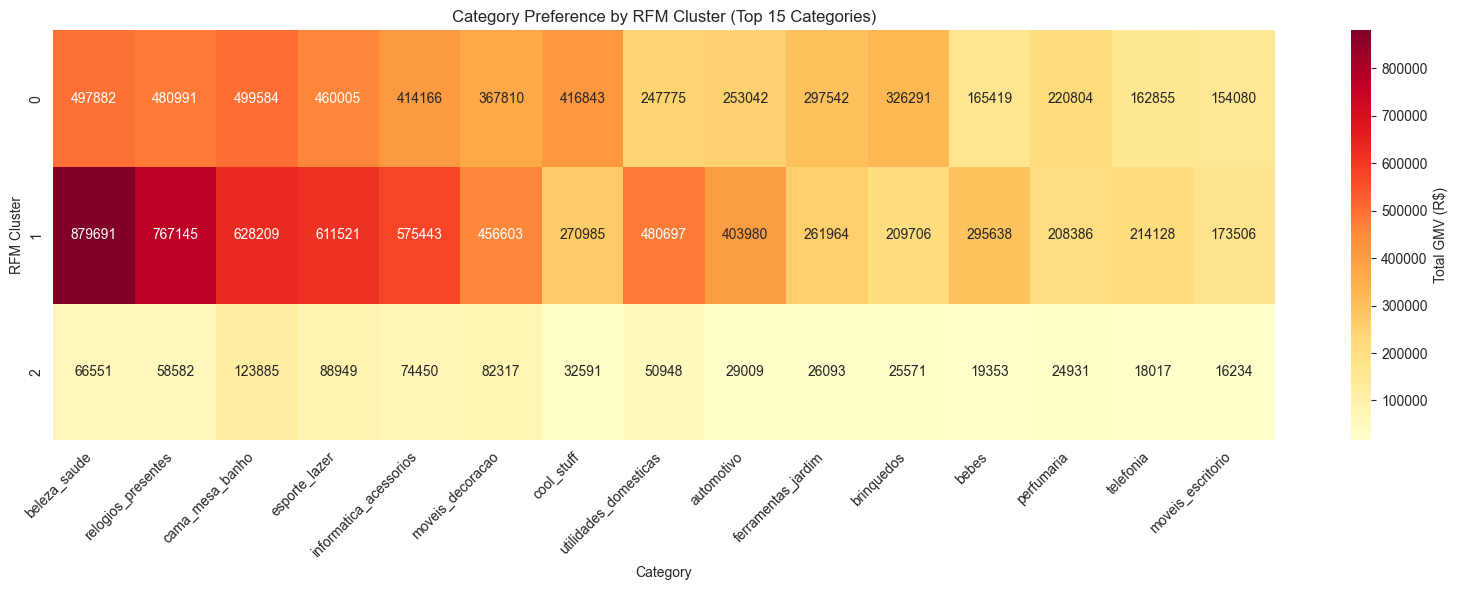

In [51]:
# heatmap of category preference by cluster
plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot_top15,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "Total GMV (R$)"}
)

plt.title("Category Preference by RFM Cluster (Top 15 Categories)")
plt.xlabel("Category")
plt.ylabel("RFM Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

###  Heatmap of Category Preference by RFM Cluster Analysis

The heatmap shows that `cluster 1` contributes the highest GMV across most of the top 15 categories, especially in `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, and `esporte_lazer`. This suggests that `cluster 1` is the commercially most important customer group in terms of overall spending.

By contrast, `cluster 2` has much lower GMV across almost all categories, although `cama_mesa_banho` remains its most prominent category. `cluster 0` sits between the other two groups and shows relatively balanced demand across several core categories. Overall, the three clusters share similar core categories, but their spending scale differs clearly, with `cluster 1` dominating the platform’s main revenue categories.

### 5.6 Revenue Share Heatmap within Each RFM Cluster

To reduce the influence of cluster size, category preference is further compared using within-cluster revenue share rather than absolute GMV. This makes it easier to examine the relative preference structure of each customer segment.

In [52]:
# create pivot table based on within-cluster revenue share
pivot_cluster_share = category_by_cluster.pivot(
    index="cluster",
    columns="category",
    values="revenue_pct"
).fillna(0)

pivot_share_top15 = pivot_cluster_share[top15_categories]

display(pivot_share_top15)

category,beleza_saude,relogios_presentes,cama_mesa_banho,esporte_lazer,informatica_acessorios,moveis_decoracao,cool_stuff,utilidades_domesticas,automotivo,ferramentas_jardim,brinquedos,bebes,perfumaria,telefonia,moveis_escritorio
cluster,,,,,,,,,,,,,,,
0,7.918994,7.650341,7.946069,7.316540,6.587457,5.850150,6.630036,3.940957,4.024731,4.732510,5.189768,2.631048,3.51196,2.590271,2.450702
1,10.434162,9.099238,7.451293,7.253354,6.825425,5.415843,3.214196,5.701622,4.791670,3.107204,2.487356,3.506607,2.47170,2.539811,2.057978
2,6.941761,6.110472,12.922052,9.277978,7.765620,8.586247,3.399487,5.314232,3.025812,2.721698,2.667266,2.018611,2.60052,1.879267,1.693269


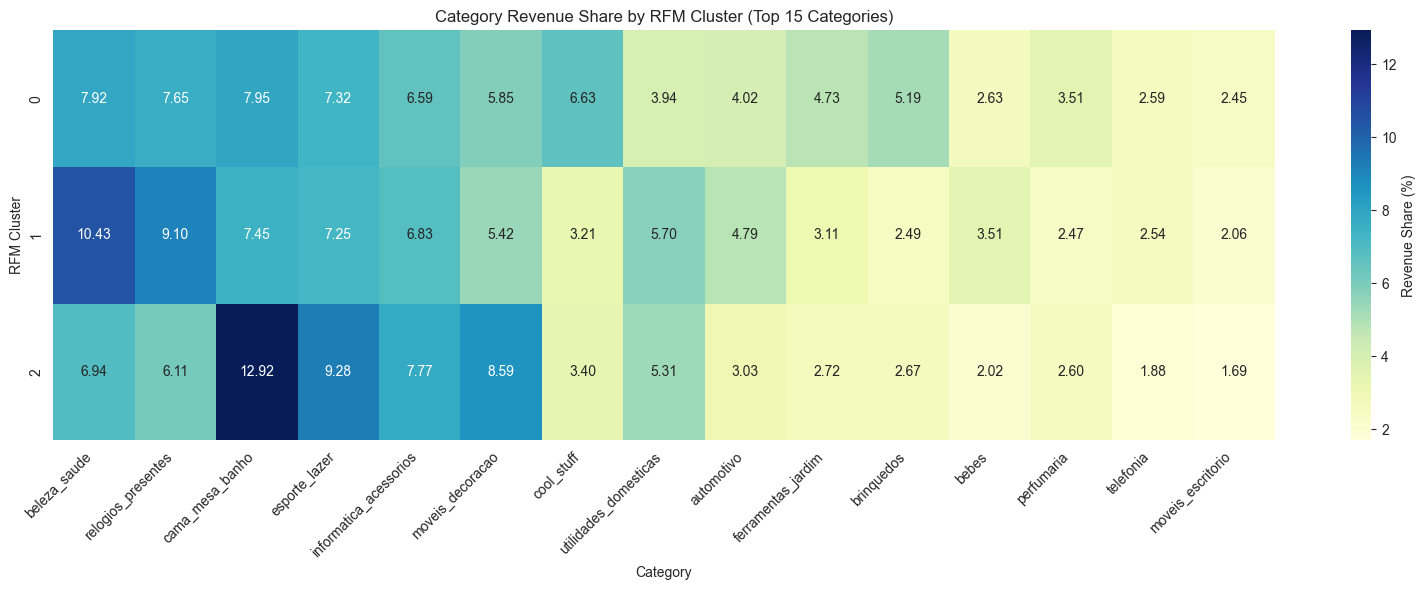

In [53]:
# heatmap of within-cluster revenue share
plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot_share_top15,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Revenue Share (%)"}
)

plt.title("Category Revenue Share by RFM Cluster (Top 15 Categories)")
plt.xlabel("Category")
plt.ylabel("RFM Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Revenue Share Heatmap within Each RFM Cluster Analysis
The revenue-share heatmap reveals clearer differences in category preference structure across the three RFM clusters. In `cluster 1`, categories such as `beleza_saude` and `relogios_presentes` account for the largest shares, suggesting a stronger preference for these commercially important categories. In `cluster 0`, the preference structure is more balanced, with `cama_mesa_banho`, `beleza_saude`, `relogios_presentes`, and `esporte_lazer` contributing similar shares.

`Cluster 2` shows the most concentrated category structure. In this group, `cama_mesa_banho` accounts for the highest share by a clear margin, followed by `esporte_lazer` and `moveis_decoracao`. This suggests that although the three clusters share several core categories, their internal spending priorities are not identical, and `cluster 2` appears to rely more heavily on a smaller set of categories.

## 6. Price Analysis
After examining category performance and customer preference, the next step is to analyse pricing patterns across categories. This section focuses on category price range, the relationship between price and satisfaction, and the pricing structure od selected categories.

### 6.1 Category Price Range Distribution
To compare category pricing structure, price statistics are calculated at the category level. This helps reveal whether different categories operate in narrow or wide price bands, and whether their average price and median price are aligned.

In [54]:
# calculate price statistics by category
price_stats = (
    df_orders.groupby("category")["price"]
    .agg(["min", "max", "mean", "median", "std", "count"])
    .reset_index()
)

price_stats = price_stats.rename(columns={"count":"order_count"})
price_stats = price_stats.sort_values("order_count", ascending=False).head(15)

display(price_stats)

,category,min,max,mean,median,std,order_count
13,cama_mesa_banho,6.99,1999.98,93.278277,79.025,82.011315,11208
11,beleza_saude,1.20,3124.00,129.949990,79.900,179.293484,9704
32,esporte_lazer,4.50,4059.00,114.217009,78.000,162.181908,8678
54,moveis_decoracao,4.90,1899.00,87.531685,65.490,88.724887,8375
44,informatica_acessorios,3.90,3699.99,116.512455,81.990,169.729104,7863
72,utilidades_domesticas,3.06,6735.00,90.698036,59.700,141.402349,6979
66,relogios_presentes,8.99,3999.90,201.007905,129.000,256.658818,6000
70,telefonia,5.00,2428.00,71.181926,29.990,135.726144,4548
40,ferramentas_jardim,6.35,3930.00,111.559759,59.900,200.357913,4360
8,automotivo,3.49,2258.00,139.813259,84.900,211.302686,4243


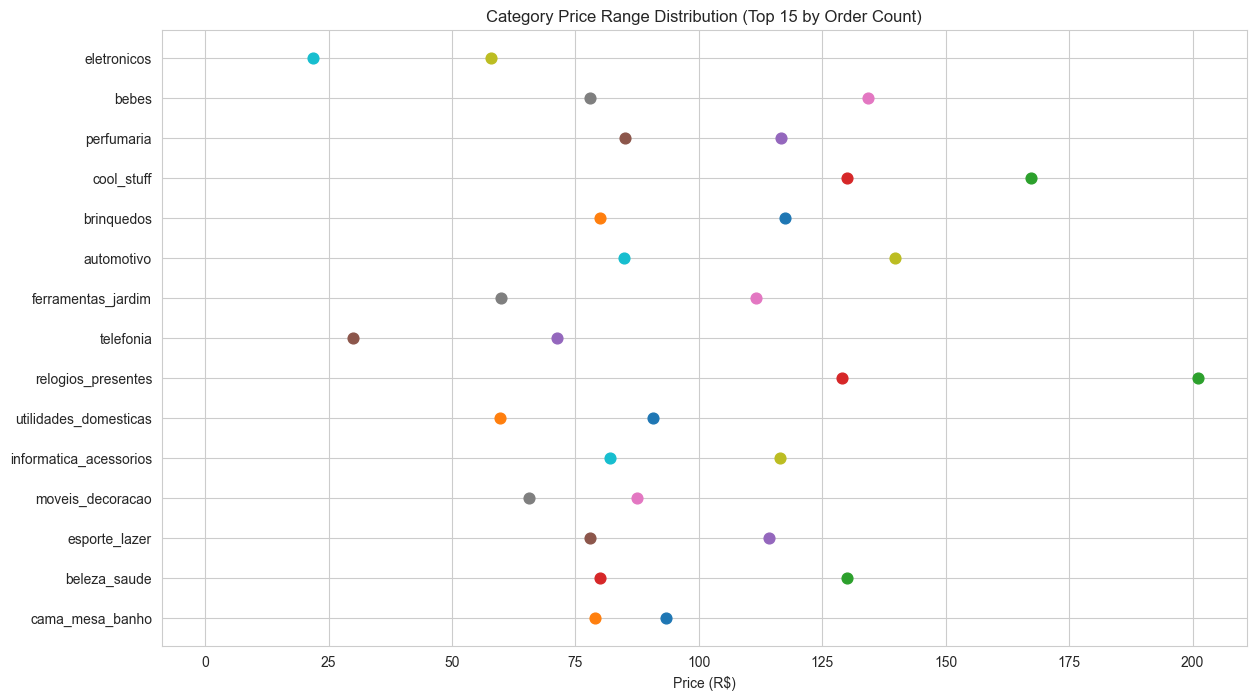

In [55]:
#  visualise price range for top 15 categories by order
fig, ax = plt.subplots(figsize=(14, 8))

for i, row in price_stats.iterrows():
    y_pos = list(price_stats.index).index(i)
    ax.plot([row["min"], row["min"]], [y_pos, y_pos], linewidth=2)
    ax.scatter(row["mean"], y_pos, marker="o", s=60, label="Mean" if y_pos == 0 else "")
    ax.scatter(row["median"], y_pos, marker="o", s=60, label="Median" if y_pos == 0 else "")

ax.set_yticks(range(len(price_stats)))
ax.set_yticklabels(price_stats["category"])
ax.set_xlabel("Price (R$)")
ax.set_title("Category Price Range Distribution (Top 15 by Order Count)")

plt.show()

### Category Price Range Distribution Analysis
The price statistics show that the leading categories differ substantially in both price level and price dispersion. Categories such as `relogios_presentes` and `cool_stuff` have relatively high mean and median prices, indicating a stronger presence in higher-value product ranges. By contrast, categories such as `telefonia` and`eletronicos` have much lower median prices, suggesting that a large share of their transactions is concentrated in lower-priced items.
The wide gaps between minimum and maximum prices, together with large standard deviations in categories such as `utilidades_domestices`, `automotivo`, and `bebes`, suggest substantial internal price variation. In many categories, the mean price is also clearly higher than the median price, which implies right-skewed price distributions and the presence of higher-priced products pulling the average upward.

### 6.2 Relationship between Price and Satisfaction
After examining category price ranges, the next step is to explore whether pricing level is associated with customer satisfaction. At the category level, this can be examined by comparing `avg_price` with `avg_review_score`.

In [56]:
# correlation between average price and average review score
price_satisfaction_corr = df_category[["avg_price", "avg_review_score"]].corr()

display(price_satisfaction_corr)

,avg_price,avg_review_score
avg_price,1.000000,0.017727
avg_review_score,0.017727,1.000000


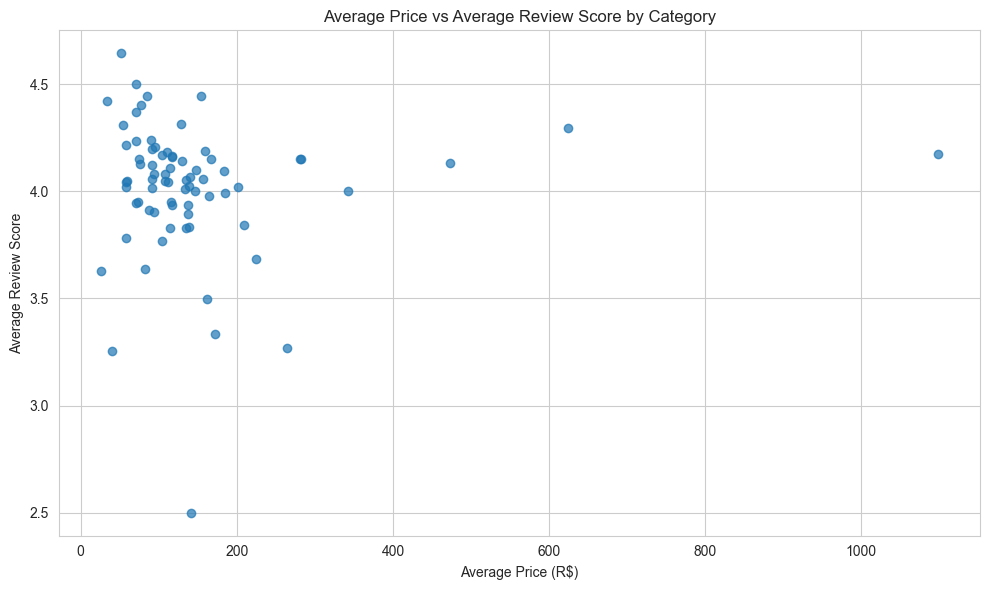

In [57]:
# scatter plot: average price vs average review score
plt.figure(figsize=(10, 6))
plt.scatter(
    df_category["avg_price"],
    df_category["avg_review_score"],
    alpha=0.7
)

plt.xlabel("Average Price (R$)")
plt.ylabel("Average Review Score")
plt.title("Average Price vs Average Review Score by Category")
plt.tight_layout()
plt.show()

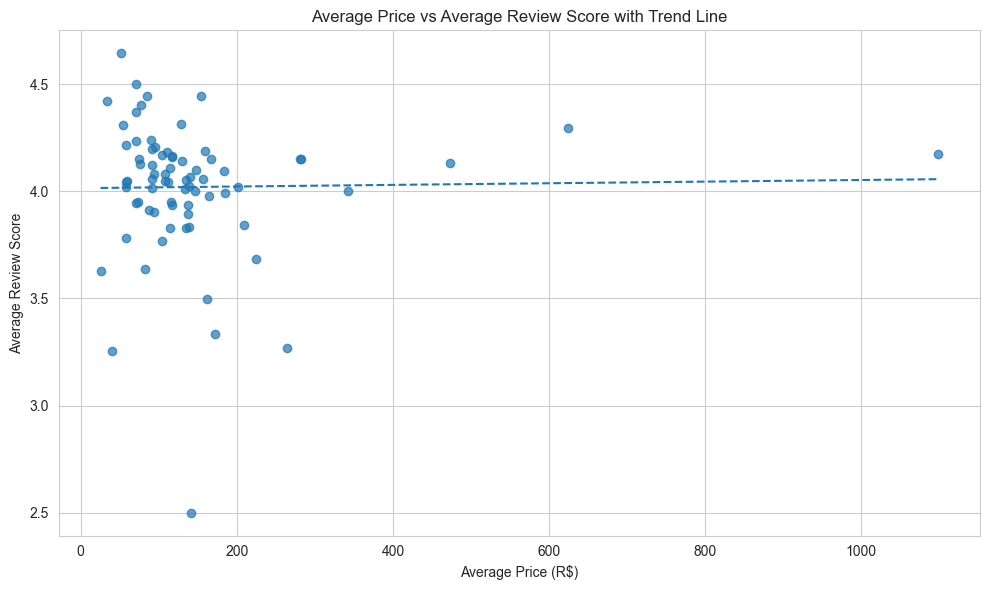

In [58]:
# add linear trend line
x = df_category["avg_price"]
y = df_category["avg_review_score"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7)
plt.plot(x.sort_values(), p(x.sort_values()), linestyle="--")

plt.xlabel("Average Price (R$)")
plt.ylabel("Average Review Score")
plt.title("Average Price vs Average Review Score with Trend Line")
plt.tight_layout()
plt.show()

### Relationship between Price and Satisfaction Analysis
The correlation between `avg_price` and `abg_review_score` is extremely weak, with a coefficient of any **0.0177**. This suggests that, at the category level, pricing has almost no linear relationship with customer satisfaction.
The scatter plot supports this result. Most categories are concentrated in the lower-to-middle price range, while their review scores remain clustered around **4.0**. The trend line is nearly flat, indicating that higher-priced categories do not systematically receive better or worse reviews than lower-prices categories.

### 6.3 Price Elasticity within a Selected Category
To examine whether demand changes across different price levels, a simple price-elasticity analysis is conducted for one representative category. The category with the highest order volume is selected, so that the result is based on relatively large number of observations.

In [59]:
# select the category with the highest order count
top_category = (
    df_category.sort_values("order_count", ascending=False)
    .iloc[0]["category"]
)

print("Selected category:", top_category)

Selected category: cama_mesa_banho


In [60]:
# filter order-level data for the selected category
df_top_category = df_orders[df_orders["category"] == top_category].copy()

print(df_top_category.shape)
df_top_category[["category", "price", "gmv"]].head()

(11208, 12)


,category,price,gmv
12,cama_mesa_banho,74.0,97.32
20,cama_mesa_banho,47.9,56.78
37,cama_mesa_banho,39.0,55.11
47,cama_mesa_banho,99.0,112.71
51,cama_mesa_banho,69.9,87.90


In [61]:
# create price bins
df_top_category["price_bin"] = pd.cut(df_top_category["price"], bins=10)

price_elasticity = (
    df_top_category.groupby("price_bin")
    .agg(
        avg_price=("price", "mean"),
        quantity=("order_id", "count")
    )
    .reset_index()
)

display(price_elasticity)

,price_bin,avg_price,quantity
0,"(4.997, 206.289]",81.700843,10656
1,"(206.289, 405.588]",257.442055,477
2,"(405.588, 604.887]",481.598409,44
3,"(604.887, 804.186]",681.398571,14
4,"(804.186, 1003.485]",894.584286,7
5,"(1003.485, 1202.784]",1081.550000,3
6,"(1202.784, 1402.083]",1256.550000,2
7,"(1601.382, 1800.681]",1740.000000,2
8,"(1800.681, 1999.98]",1943.046667,3


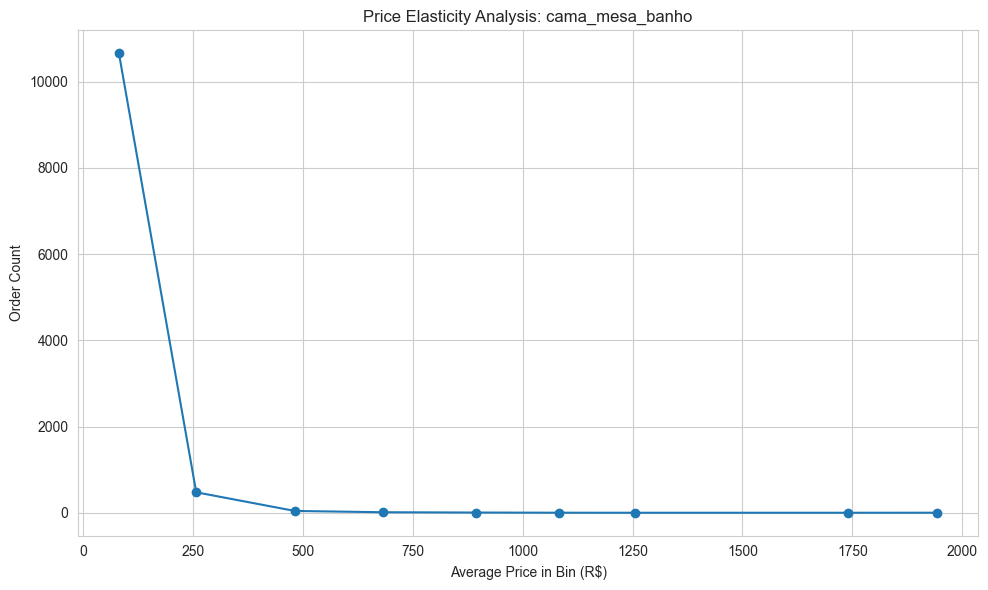

In [62]:
# visualise quantity by price bin
plt.figure(figsize=(10, 6))
plt.plot(price_elasticity["avg_price"], price_elasticity["quantity"], marker="o")

plt.xlabel("Average Price in Bin (R$)")
plt.ylabel("Order Count")
plt.title(f"Price Elasticity Analysis: {top_category}")
plt.tight_layout()
plt.show()

### 6.3 Price Elasticity within a Selected Category Analysis

The selected category for the price-elasticity example is `cama_mesa_banho`, which has the highest order volume and therefore provides a relatively stable basis for analysis. The price-bin result shows that most orders are concentrated in the lowest price interval, where the average price is around **R$81.70** and the order count exceeds **10,000**.

As price increases, the number of orders drops sharply. Higher price intervals contain only a very small number of transactions, and the curve declines rapidly after the first bin. This suggests that demand in `cama_mesa_banho` is strongly concentrated in the lower price range, while high-priced products represent only a small niche within the category.

## 7. Time Series Analysis

After examining category performance, customer preference, and pricing patterns, the next step is to analyse category sales over time. This section focuses on monthly sales trends, growth patterns, and seasonal variation across product categories.

### 7.1 Preparing Monthly Category Sales Data
To analyse category trends over time, the order-level dataset is first aggregated at the monthly category level. This creates a time-based view of sales performance that can be used for later trend and growth analysis.

In [63]:
# create monthly variable
df_orders["month"] = pd.to_datetime(df_orders["purchase_ts"]).dt.to_period("M")


In [64]:
# aggregate monthly sales by category
monthly_sales = (
    df_orders.groupby(["month", "category"])
    .agg(
        total_gmv=("gmv", "sum"),
        order_count=("order_id", "count")
    )
    .reset_index()
)

monthly_sales["month"] = monthly_sales["month"].dt.to_timestamp()

print(monthly_sales.shape)
display(monthly_sales.head(20))

(1262, 4)


,month,category,total_gmv,order_count
0,2016-09-01,beleza_saude,143.46,3
1,2016-09-01,moveis_decoracao,136.23,2
2,2016-09-01,telefonia,75.06,1
3,2016-10-01,alimentos,96.23,1
4,2016-10-01,audio,183.03,2
5,2016-10-01,automotivo,2257.56,12
6,2016-10-01,bebes,1819.08,14
7,2016-10-01,beleza_saude,5493.38,48
8,2016-10-01,brinquedos,4986.08,27
9,2016-10-01,cama_mesa_banho,606.58,8


### Monthly Category Sales Data Analysis
The monthly sales table contains **1,262 month-category observations**, which provides a structured time-series basis for tracking category performance over time. Each row represents the monthly GMV and order count of one product category, making it suitable for later trend comparison across categories.
The table also sjows that category activity starts from **2016-09** and becomes more populated from **2016-10** onward. This suggests that the monthly aggregation has been created correctly and can support the following analysis of top-category sales trends and growth patterns.

### 7.2 Monthly Sales Trend of Top Categories
To compare category development over time, the monthly GMV trend of the top revenue categories is visualised. Focusing on the leading categories helps reveal whether their sales patterns are stable, growing, or volatile across the observed period.

In [65]:
# select top 5 categories by  total revenue
top5_categories = (
    df_category.sort_values("total_revenue", ascending=False)
    .head(5)["category"]
    .tolist()
)

print(top5_categories)

['beleza_saude', 'relogios_presentes', 'cama_mesa_banho', 'esporte_lazer', 'informatica_acessorios']


In [66]:
# filter monthly sales for top 5 categoris
monthly_top5 = monthly_sales[
    monthly_sales["category"].isin(top5_categories)
].copy()

display(monthly_top5.head(20))

,month,category,total_gmv,order_count
0,2016-09-01,beleza_saude,143.46,3
7,2016-10-01,beleza_saude,5493.38,48
9,2016-10-01,cama_mesa_banho,606.58,8
14,2016-10-01,esporte_lazer,3927.11,19
22,2016-10-01,informatica_acessorios,1740.09,21
30,2016-10-01,relogios_presentes,3468.04,5
39,2017-01-01,beleza_saude,14039.74,85
41,2017-01-01,cama_mesa_banho,4944.77,49
51,2017-01-01,esporte_lazer,11856.71,86
58,2017-01-01,informatica_acessorios,4377.60,31


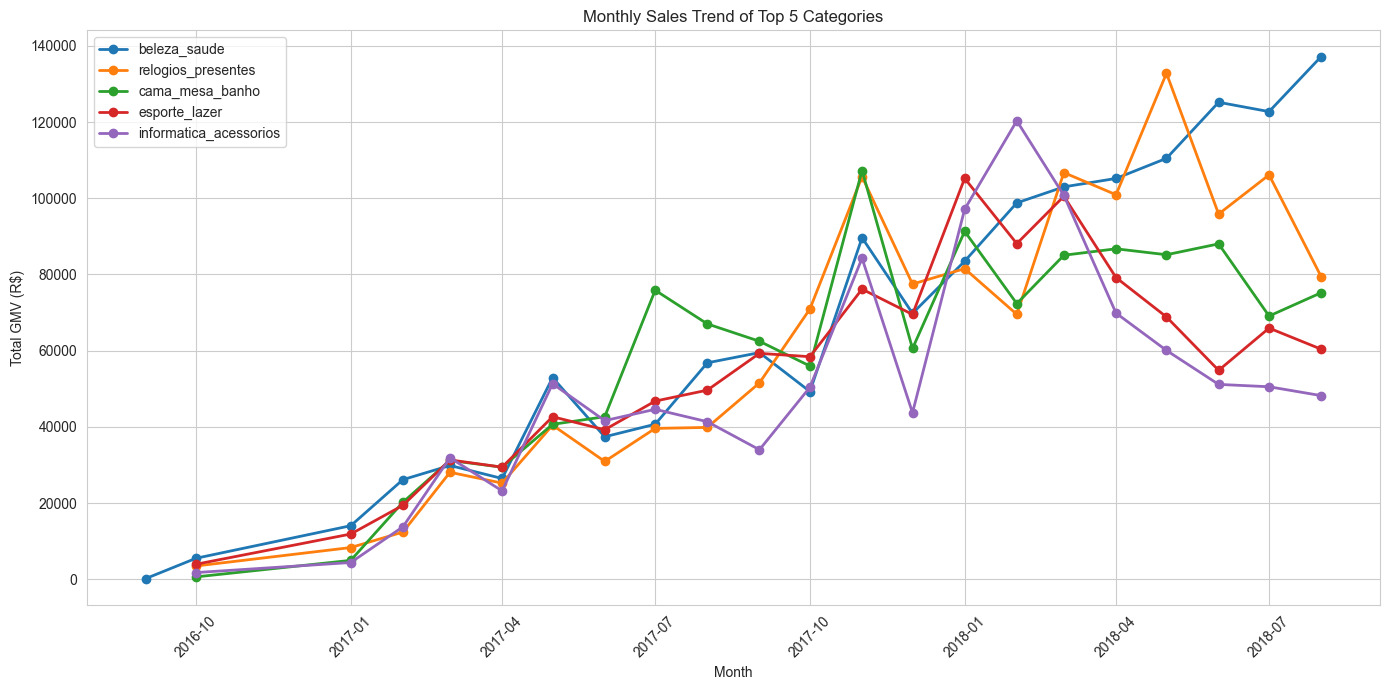

In [67]:
# line chart: monthly GMV trend of top 5 categories
plt.figure(figsize=(14, 7))

for cat in top5_categories:
    cat_data = monthly_top5[monthly_top5["category"] == cat]
    plt.plot(
        cat_data["month"],
        cat_data["total_gmv"],
        marker="o",
        linewidth=2,
        label=cat
    )

plt.xlabel("Month")
plt.ylabel("Total GMV (R$)")
plt.title("Monthly Sales Trend of Top 5 Categories")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Sales Trend of Top Categories Analysis
The monthly trend chart shows that all five leading categories experienced substantial growth over time, especially from 2017 onward. This suggests that the platform's core categories expanded rapidly during the main observation period, although the growth paths were not fully stable.
Among these categories, `beleza_saude` shows the strongest upward trend and reaches the highest sales level toward the end of the period. `relogios_presentes` and `informatica_acessorios` appear more volatile, with sharper rises and declines across months. By contrast, `cama_mesa_banho` and `esporte_lazer` maintain relatively strong performance throughout the period, but their trends are still affected by noticeable month-to-month fluctuations.

### 7.3 Category Growth Rate Analysis
To further compare category development speed, monthly growth rate is calculated based on category GMV. This helps identify which categories expand faster over time and which categories show weaker or more unstable growth patterns.

In [68]:
# sort data before calculating growth rate
monthly_sales = monthly_sales.sort_values(["category","month"]).copy()

In [69]:
# calculate month-over-month growth rate for each category
monthly_sales["prev_gmv"] = monthly_sales.groupby("category")["total_gmv"].shift(1)

monthly_sales["growth_rate"] = (
    (monthly_sales["total_gmv"] - monthly_sales["prev_gmv"]) / monthly_sales["prev_gmv"] * 100
)

In [70]:
# check growth-rate result
display(
    monthly_sales[["month",  "category", "total_gmv", "prev_gmv", "growth_rate"]].head(20)
)

,month,category,total_gmv,prev_gmv,growth_rate
35,2017-01-01,agro_industria_e_comercio,107.76,NaN,NaN
78,2017-02-01,agro_industria_e_comercio,331.10,107.76,207.256867
129,2017-03-01,agro_industria_e_comercio,110.69,331.10,-66.569012
240,2017-05-01,agro_industria_e_comercio,1763.74,110.69,1493.405005
299,2017-06-01,agro_industria_e_comercio,1422.05,1763.74,-19.373037
359,2017-07-01,agro_industria_e_comercio,1199.47,1422.05,-15.652052
420,2017-08-01,agro_industria_e_comercio,224.60,1199.47,-81.275063
483,2017-09-01,agro_industria_e_comercio,2119.69,224.60,843.762244
548,2017-10-01,agro_industria_e_comercio,3558.43,2119.69,67.875019
611,2017-11-01,agro_industria_e_comercio,14610.32,3558.43,310.583319


In [71]:
# average monthly growth rate by category
avg_growth = (
    monthly_sales.groupby("category")["growth_rate"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_growth.head(10))

category
fashion_bolsas_e_acessorios                      524.243701
artes                                            388.000094
construcao_ferramentas_seguranca                 363.668164
dvds_blu_ray                                     306.324612
moveis_decoracao                                 261.144880
portateis_cozinha_e_preparadores_de_alimentos    260.954396
artigos_de_festas                                259.300026
artes_e_artesanato                               247.734614
beleza_saude                                     200.609615
musica                                           184.916593
Name: growth_rate, dtype: float64

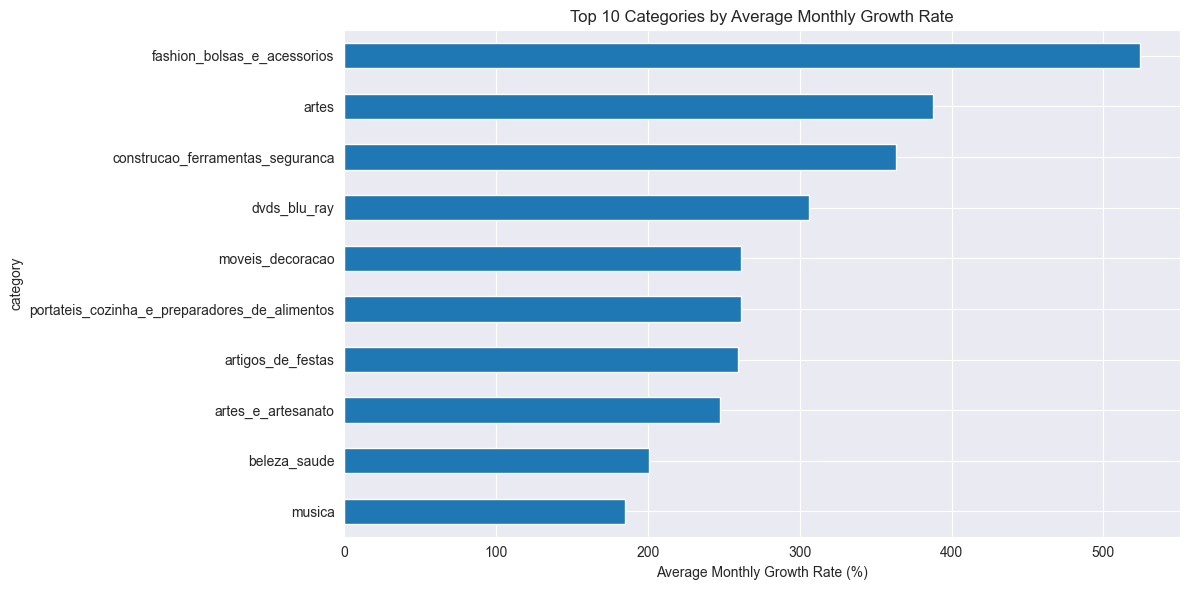

In [72]:
# visualise top 10 categories by average monthly growth rate
plt.figure(figsize=(12, 6))

avg_growth.head(10).sort_values().plot(kind="barh")

plt.xlabel("Average Monthly Growth Rate (%)")
plt.title("Top 10 Categories by Average Monthly Growth Rate")
plt.tight_layout()
plt.show()

### Category Growth Rate Analysis
The average monthly growth-rate ranking suggests that some categories experienced very rapid expansion during the observed period. Categories such as `fashion_bolsas_e_acessorios`, `artes`, and `construcao_ferramentas_seguranca` show the highest average growth rates, indicating strong upward changes in monthly GMV.
However, these results should be interpreted with caution because monthly growth rate is highly sensitive to low initial sales levels. Extremely high percentages may reflect small-base effects rather than stable long-term expansion. Among the top categories, `beleza_saude` is particularly notable because it appears not only as a fast-growing category but also as a major revenue contributor, which makes its growth pattern more commercially meaningful than that of some smaller categories.

### 7.4 Quarterly Sales Pattern of Top Categories
To further examine possible seasonal differences, category sales are aggregated at the quarterly level. This provides a simpler view of whether the leading categories show relatively stronger performance in specific parts of the year.

In [73]:
# extract quarter from purchase timestamp
df_orders["quarter"] = pd.to_datetime(df_orders["purchase_ts"]).dt.quarter

In [74]:
# aggregate quarterly sales by category
quarterly_sales = (
    df_orders.groupby(["quarter", "category"])
    .agg(
        total_gmv=("gmv", "sum"),
        order_count=("order_id", "count")
    )
    .reset_index()
)

display(quarterly_sales.head(20))

,quarter,category,total_gmv,order_count
0,1,agro_industria_e_comercio,21472.78,85
1,1,alimentos,9806.86,129
2,1,alimentos_bebidas,4708.95,59
3,1,artes,5327.54,44
4,1,artigos_de_festas,1240.55,8
5,1,artigos_de_natal,4970.10,46
6,1,audio,20151.59,94
7,1,automotivo,180407.47,1142
8,1,bebes,127055.80,745
9,1,bebidas,7319.82,110


In [76]:
# keep only top 5 categories by total revenue
quarterly_top5 = quarterly_sales[
    quarterly_sales["category"].isin(top5_categories)
].copy()

display(quarterly_top5.head(20))

,quarter,category,total_gmv,order_count
10,1,beleza_saude,355273.54,2441
12,1,cama_mesa_banho,305013.42,2869
30,1,esporte_lazer,356390.69,2513
42,1,informatica_acessorios,368178.81,2786
63,1,relogios_presentes,306523.07,1267
81,2,beleza_saude,457616.49,3093
83,2,cama_mesa_banho,372635.09,3310
102,2,esporte_lazer,314149.46,2335
114,2,informatica_acessorios,297152.79,2133
136,2,relogios_presentes,426153.84,1983


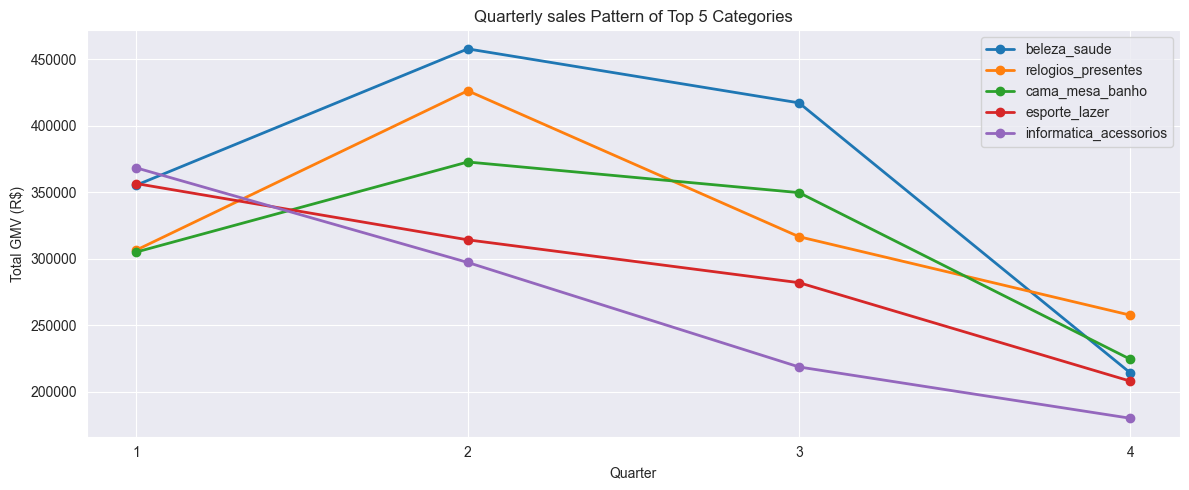

In [77]:
# line chart: quarterly GMV of top 5 categories
plt.figure(figsize=(12, 5))

for cat in top5_categories:
    cat_data = quarterly_top5[quarterly_top5["category"] == cat]
    plt.plot(
        cat_data["quarter"],
        cat_data["total_gmv"],
        marker="o",
        linewidth=2,
        label=cat
    )

plt.xlabel("Quarter")
plt.ylabel("Total GMV (R$)")
plt.title("Quarterly sales Pattern of Top 5 Categories")
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

### Quarterly Sales Pattern of Top Categories Analysis
The quarterly pattern shows that most top categories perform strongest in **Q2**, where `beleza_saude`, `relogios_presents`, and `cama_mesa_banho` all reach relatively high sales levels. This suggests that the platform's core categories share a similar mid-year sales peak.
After Q2, most categories decline gradually through **Q3** and **Q4**. Among them, `information_acessorios` show s the clearest downward pattern across the four quarters, while `beleza_saude` remains the strongest category overall despite a notable drop in Q4. Overall, the top categories display some common quarterly variation, with stronger performance in the middle of the year and weaker results toward the end of the year.

## 8. Geographic Analysis
After analysing category performance over time, the next step is to examine geographic differences in category demand. This section focuses on how category sales very across customer states and whether different regions show different patterns.

### 8.1 Category Sales by State
To explore geographic variation, category sales are aggregated by customer state. This creates a state-category view of GMV and order volume, which can support later comparison of regional preference patterns.

In [79]:
# aggregate sales by state and category
state_category_sales = (
    df_orders.groupby(["customer_state", "category"])
    .agg(
        total_gmv=("gmv", "sum"),
        order_count=("order_id", "count")
    )
    .reset_index()
)

print(state_category_sales.shape)
display(state_category_sales.head(20))

(1368, 4)


,customer_state,category,total_gmv,order_count
0,AC,artigos_de_natal,130.85,1
1,AC,automotivo,661.91,4
2,AC,bebes,871.97,3
3,AC,beleza_saude,1655.00,7
4,AC,brinquedos,318.05,3
5,AC,cama_mesa_banho,725.21,4
6,AC,consoles_games,321.92,1
7,AC,cool_stuff,130.22,1
8,AC,eletronicos,666.68,4
9,AC,eletroportateis,100.91,1


In [81]:
# identify top 10 states by total GMV
top10_states = (
    df_orders.groupby("customer_state")["gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top10_states)

customer_state
SP    5863071.62
RJ    2107184.28
MG    1838777.35
RS     878065.50
PR     793617.66
BA     604503.49
SC     602882.37
DF     351304.72
GO     340368.16
ES     323383.71
Name: gmv, dtype: float64

### Category Sales by State Analysis
The state-category table contains **1,368 state-category combinations**, which provides a detailed basis for analysing differences in category demand. This means category sales can be compared across multiple geographic markets rather than only at the overall platform level.
The top-state ranking shows that category sales are highly concentrated in a small number of states. `SP` contributions by far the largest GMV, followed by `RJ` and `MG`, while the remaining top states are substantially smaller in scale. This suggests that the platform's category performance is strongly influenced by a few major regional markets, especially in the southeast of Brazil.

### 8.2 Heatmap of Category Sales by State
To compare regional category preference more clearly, a heatmap is created for the top states amd the major revenue categories. This makes it easier to observe whether different states show similar or different category demand structures.

In [82]:
# keep only top 10 states
top10_state_list = top10_states.index.tolist()

state_category_top10 = state_category_sales[
    state_category_sales["customer_state"].isin(top10_state_list)
].copy()

In [83]:
# select top 15 categories by total revenue
top15_categories_geo = (
    df_category.sort_values("total_revenue", ascending=False)
    .head(15)["category"]
    .tolist()
)

print(top15_categories_geo)

['beleza_saude', 'relogios_presentes', 'cama_mesa_banho', 'esporte_lazer', 'informatica_acessorios', 'moveis_decoracao', 'cool_stuff', 'utilidades_domesticas', 'automotivo', 'ferramentas_jardim', 'brinquedos', 'bebes', 'perfumaria', 'telefonia', 'moveis_escritorio']


In [84]:
# create pivot table: state × category
pivot_state_category = state_category_top10.pivot(
    index="customer_state",
    columns="category",
    values="total_gmv"
).fillna(0)

pivot_state_top15 = pivot_state_category[top15_categories_geo]

display(pivot_state_top15)

category,beleza_saude,relogios_presentes,cama_mesa_banho,esporte_lazer,informatica_acessorios,moveis_decoracao,cool_stuff,utilidades_domesticas,automotivo,ferramentas_jardim,brinquedos,bebes,perfumaria,telefonia,moveis_escritorio
customer_state,,,,,,,,,,,,,,,
BA,60254.07,53789.79,32459.75,46618.58,39630.40,30754.44,27734.00,22246.52,34247.82,29825.34,17747.78,18353.65,11471.81,25688.79,18923.63
DF,34567.72,35589.67,20849.40,27707.97,28455.11,15538.83,14267.27,16575.57,20130.57,10668.42,13849.54,10210.60,11370.67,7718.73,3884.40
ES,23851.84,32094.41,27265.64,23938.40,18084.18,16320.37,12487.14,15049.65,14199.17,13609.61,12456.00,9904.85,7731.13,11183.92,6818.33
GO,33781.26,36031.50,28122.96,23294.13,16776.95,15825.22,25647.35,18640.04,13558.86,18613.41,9551.51,11359.40,11920.04,8207.25,4118.62
MG,178980.48,134686.20,158926.03,133532.60,129590.00,99646.19,82950.66,96804.46,84283.48,73535.42,68634.00,56608.21,55560.08,42960.55,35853.82
PR,62777.38,65269.61,55833.14,67921.95,51316.82,62141.81,42057.56,38695.62,33895.47,25667.79,28159.67,25367.79,18277.77,17264.41,20450.85
RJ,165010.22,199298.21,181035.41,147031.53,141904.44,122934.71,95695.74,97689.05,75819.67,90066.75,84573.13,50798.81,61077.62,45619.00,59947.34
RS,60624.05,52150.82,73352.53,64125.06,63030.49,67649.89,52623.29,48909.97,30938.13,43531.45,33597.21,35781.86,23383.30,24146.26,13417.46
SC,46063.88,36406.57,38619.00,51488.30,44093.41,40381.40,31860.28,33272.30,32101.32,27963.50,18188.63,19880.41,15953.10,15058.45,13186.78


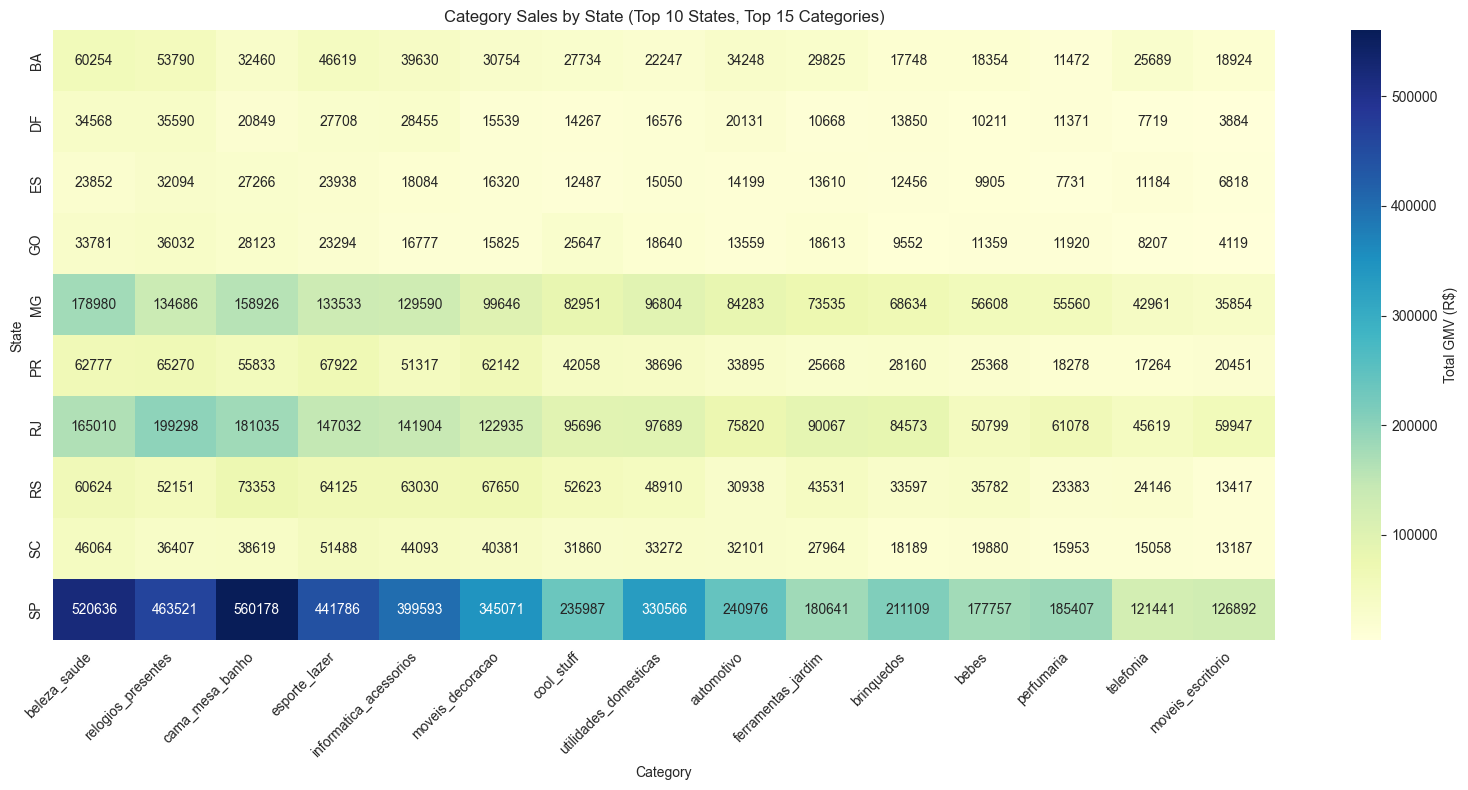

In [85]:
# heatmap of category sales by state
plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_state_top15,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    cbar_kws={"label": "Total GMV (R$)"}
)

plt.title("Category Sales by State (Top 10 States, Top 15 Categories)")
plt.xlabel("Category")
plt.ylabel("State")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Heatmap of Category Sales by State Analysis

The heatmap shows that `SP` dominates category sales across almost all major categories, with especially strong performance in `cama_mesa_banho`, `beleza_saude`, `relogios_presentes`, and `esporte_lazer`. `RJ` and `MG` also contribute strongly, but their sales levels remain noticeably below those of `SP`.

Although the scale differs across states, the leading categories are broadly similar in most major regions. Categories such as `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, and `esporte_lazer` appear repeatedly as high-value categories across the top states. This suggests that regional differences exist more in sales scale than in the overall structure of core category demand.

### 8.3 Top Categories within Each State

To make regional differences more interpretable, the top categories within each major state are identified based on total GMV. This helps show which categories contribute most strongly to each regional market.

In [86]:
# top 3 categories within each top state
for state in top10_state_list:
    print(f"\nTop 3 categories in {state}:")

    top3_state = (
        state_category_top10[state_category_top10["customer_state"] == state]
        .sort_values("total_gmv", ascending=False)
        .head(3)
    )

    display(top3_state[["customer_state", "category", "total_gmv", "order_count"]])


Top 3 categories in SP:


,customer_state,category,total_gmv,order_count
1271,SP,cama_mesa_banho,560177.54,5278
1269,SP,beleza_saude,520635.92,4216
1324,SP,relogios_presentes,463521.22,2284



Top 3 categories in RJ:


,customer_state,category,total_gmv,order_count
978,RJ,relogios_presentes,199298.21,875
926,RJ,cama_mesa_banho,181035.41,1650
924,RJ,beleza_saude,165010.22,1069



Top 3 categories in MG:


...

,customer_state,category,total_gmv,order_count
296,DF,relogios_presentes,35589.67,148
252,DF,beleza_saude,34567.72,246
278,DF,informatica_acessorios,28455.11,164



Top 3 categories in GO:


,customer_state,category,total_gmv,order_count
417,GO,relogios_presentes,36031.50,147
369,GO,beleza_saude,33781.26,230
371,GO,cama_mesa_banho,28122.96,240



Top 3 categories in ES:


,customer_state,category,total_gmv,order_count
354,ES,relogios_presentes,32094.41,152
314,ES,cama_mesa_banho,27265.64,228
330,ES,esporte_lazer,23938.40,174


### Top Categories within Each State Analysis

The top-category lists show that the leading categories are broadly similar across major states, with `beleza_saude`, `cama_mesa_banho`, and `relogios_presentes` appearing frequently among the top positions. This suggests that the platform’s strongest categories maintain broad appeal across different regional markets.

At the same time, some state-level differences are still visible. For example, `SP` is led by `cama_mesa_banho`, while `RJ`, `DF`, `GO`, and `ES` show stronger performance in `relogios_presentes`. In the southern states such as `RS` and `SC`, categories like `moveis_decoracao`, `esporte_lazer`, and `informatica_acessorios` become more prominent. This indicates that regional demand structure is similar overall, but some categories are relatively more important in specific states.

## 9. Statistical Analysis

After examining category performance from descriptive and visual perspectives, the next step is to apply statistical analysis. This section tests whether category differences are associated with satisfaction outcomes and pricing patterns in a statistically meaningful way.

### 9.1 Chi-square Test: Category and Satisfaction Level

To test whether customer satisfaction differs across product categories, review scores are first grouped into broader satisfaction levels. A chi-square test is then applied to examine whether category and satisfaction level are statistically associated.

In [87]:
# create satisfaction-level variable from review score
df_review["satisfaction_level"] = pd.cut(
    df_review["review_score"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Medium", "High"]
)

In [88]:
# keep only top 10 categories by order count
top10_categories_stats = (
    df_category.sort_values("order_count", ascending=False)
    .head(10)["category"]
    .tolist()
)

print(top10_categories_stats)

['cama_mesa_banho', 'beleza_saude', 'esporte_lazer', 'informatica_acessorios', 'moveis_decoracao', 'utilidades_domesticas', 'relogios_presentes', 'telefonia', 'automotivo', 'brinquedos']


In [89]:
# filter review data for top 10 categories
df_chi = df_review[
    df_review["category"].isin(top10_categories_stats)
].copy()

print(df_chi.shape)
display(df_chi[["category", "review_score", "satisfaction_level"]].head())

(70644, 13)


,category,review_score,satisfaction_level
2,moveis_decoracao,5.0,High
5,utilidades_domesticas,4.0,High
6,telefonia,4.0,High
8,beleza_saude,1.0,Low
10,beleza_saude,5.0,High


In [90]:
# build contingency table
contingency_table = pd.crosstab(
    df_chi["category"],
    df_chi["satisfaction_level"]
)

display(contingency_table)

satisfaction_level,Low,Medium,High
category,,,
automotivo,638,322,3226
beleza_saude,1312,750,7505
brinquedos,547,311,3211
cama_mesa_banho,2056,1096,7810
esporte_lazer,1246,634,6679
informatica_acessorios,1430,642,5682
moveis_decoracao,1581,727,5882
relogios_presentes,965,531,4442
telefonia,759,459,3292


In [91]:
from scipy.stats import chi2_contingency

# chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 330.1738
p-value: 0.000000
Degrees of freedom: 18


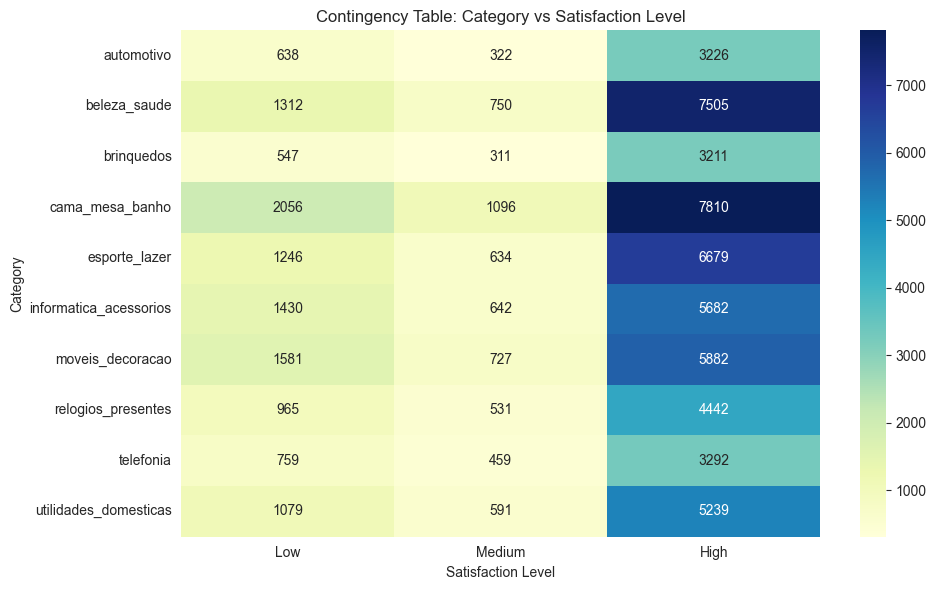

In [92]:
# heatmap of contingency table
plt.figure(figsize=(10, 6))
sns.heatmap(
    contingency_table,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Contingency Table: Category vs Satisfaction Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

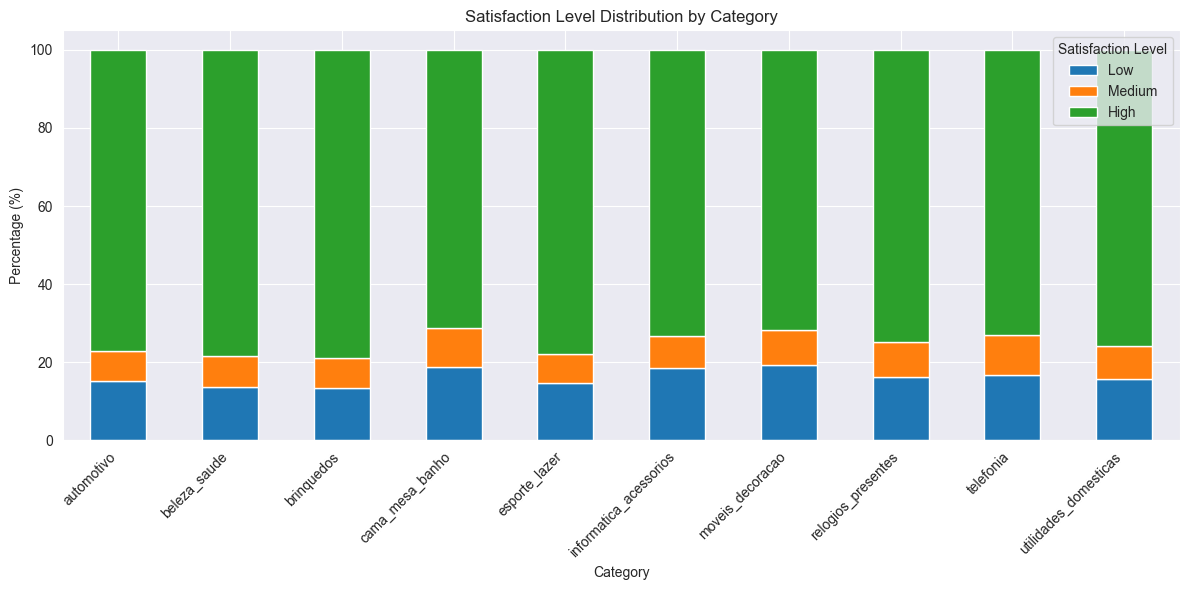

In [93]:
# convert contingency table to percentage within each category
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

# stacked bar chart
contingency_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Category")
plt.ylabel("Percentage (%)")
plt.title("Satisfaction Level Distribution by Category")
plt.legend(title="Satisfaction Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Chi-square Test: Category and Satisfaction Level Analysis

The chi-square test shows a statistically significant relationship between product category and satisfaction level. The test result is **χ² = 330.17** with **18 degrees of freedom**, and the **p-value is below 0.001**, indicating that satisfaction outcomes are not distributed evenly across categories.

The visual results support this conclusion. Although all top categories are dominated by the `High` satisfaction group, the proportion of `Low` and `Medium` satisfaction still differs across categories. Categories such as `cama_mesa_banho`, `informatica_acessorios`, and `moveis_decoracao` show relatively larger low-satisfaction shares, while categories such as `beleza_saude` and `brinquedos` appear to have relatively stronger high-satisfaction composition. This suggests that category type is meaningfully associated with customer satisfaction structure.

### 9.2 ANOVA: Price Difference across Categories
To test whether pricing differs significantly across product categories, a one-way ANOVA is applied to the top categories by order volume. This helps evaluate whether the observed price differences across categories are statistically meaningful rather than random variation.

In [95]:
from scipy.stats import f_oneway

In [96]:
# use the same top 10 categories by order count
top10_categories_stats = (
    df_category.sort_values("order_count", ascending=False)
    .head(10)["category"]
    .tolist()
)

print(top10_categories_stats)

['cama_mesa_banho', 'beleza_saude', 'esporte_lazer', 'informatica_acessorios', 'moveis_decoracao', 'utilidades_domesticas', 'relogios_presentes', 'telefonia', 'automotivo', 'brinquedos']


In [97]:
# collect price samples for each category
price_groups = []

for cat in top10_categories_stats:
    group = df_orders[df_orders["category"] == cat]["price"].dropna()
    price_groups.append(group)

    print(f"{cat}: {len(group)} observations")

cama_mesa_banho: 11208 observations
beleza_saude: 9704 observations
esporte_lazer: 8678 observations
informatica_acessorios: 7863 observations
moveis_decoracao: 8375 observations
utilidades_domesticas: 6979 observations
relogios_presentes: 6000 observations
telefonia: 4548 observations
automotivo: 4243 observations
brinquedos: 4121 observations


In [98]:
# collect price samples for each category
price_groups = []

for cat in top10_categories_stats:
    group = df_orders[df_orders["category"] == cat]["price"].dropna()
    price_groups.append(group)

    print(f"{cat}: {len(group)} observations")

cama_mesa_banho: 11208 observations
beleza_saude: 9704 observations
esporte_lazer: 8678 observations
informatica_acessorios: 7863 observations
moveis_decoracao: 8375 observations
utilidades_domesticas: 6979 observations
relogios_presentes: 6000 observations
telefonia: 4548 observations
automotivo: 4243 observations
brinquedos: 4121 observations


In [99]:
# one-way ANOVA test
f_stat, p_value = f_oneway(*price_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")

F-statistic: 328.2813
p-value: 0.000000


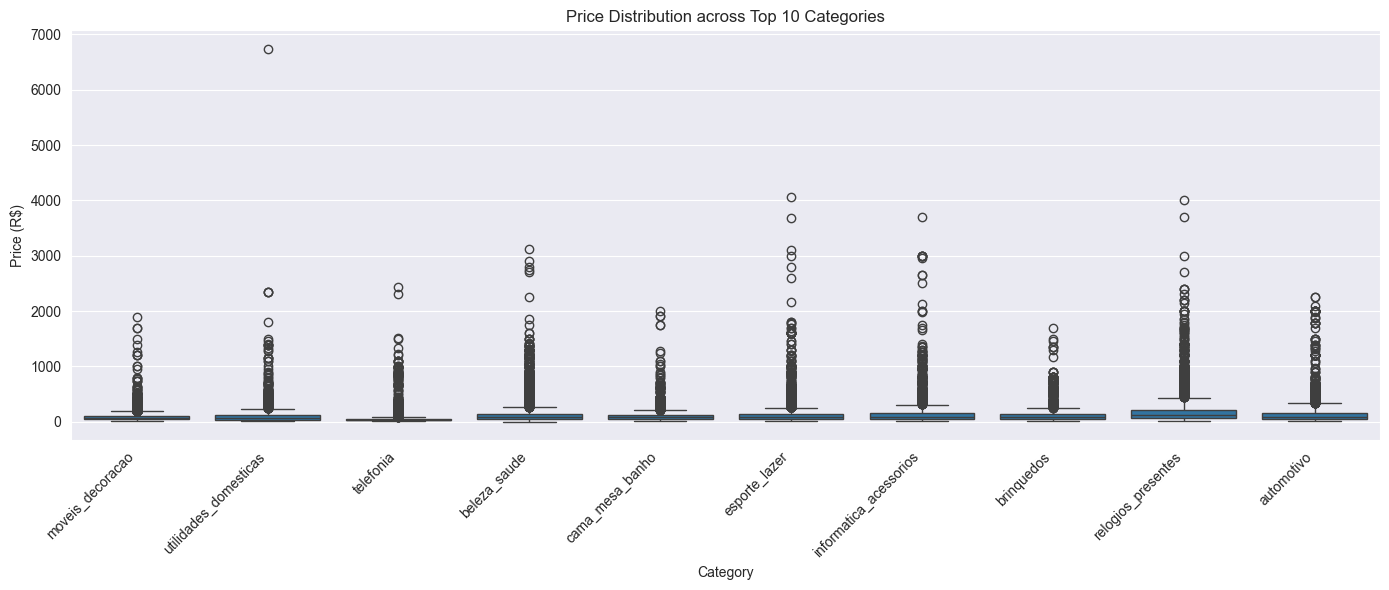

In [100]:
# boxplot of price distribution across categories
plt.figure(figsize=(14, 6))

df_box = df_orders[df_orders["category"].isin(top10_categories_stats)].copy()

sns.boxplot(
    data=df_box,
    x="category",
    y="price"
)

plt.title("Price Distribution across Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Price (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### ANOVA: Price Difference across Categories Analysis
The ANOVA result shows that price differences across the top 10 categories are statistically significant. The test gives an **F-statistic of 328.28** with a **p-value below 0.001**, indicating that the average price is not the same across these major categories.
The boxplot supports this result by showing clear differences in both central price level and price dispersion. Categories such as `relogios_presents` and `informatica_acessories` tend to have higher price distributions, while categories such as `telefonia` and `brinquedos` are concentrated at relatively lower price levels. At the same time, several categories show wide spreads and may high-value outliers, suggesting substantial internal price variation within category.

### 9.3 Correlation Analysis of Category Metrics

To further examine the relationships among key category-level indicators, a correlation analysis is conducted. This helps identify whether category size, pricing, satisfaction, and review risk tend to move together or in opposite directions.

In [101]:
# select key category-level variables for correlation analysis
corr_vars = [
    "order_count",
    "total_revenue",
    "avg_price",
    "avg_review_score",
    "bad_review_rate",
    "avg_freight"
]

corr_matrix = df_category[corr_vars].corr()

display(corr_matrix)

,order_count,total_revenue,avg_price,avg_review_score,bad_review_rate,avg_freight
order_count,1.000000,0.959820,-0.103819,0.043684,-0.048081,-0.124054
total_revenue,0.959820,1.000000,0.020118,0.045817,-0.050336,-0.043338
avg_price,-0.103819,0.020118,1.000000,0.017727,-0.005932,0.624999
avg_review_score,0.043684,0.045817,0.017727,1.000000,-0.958131,-0.028247
bad_review_rate,-0.048081,-0.050336,-0.005932,-0.958131,1.000000,-0.006144
avg_freight,-0.124054,-0.043338,0.624999,-0.028247,-0.006144,1.000000


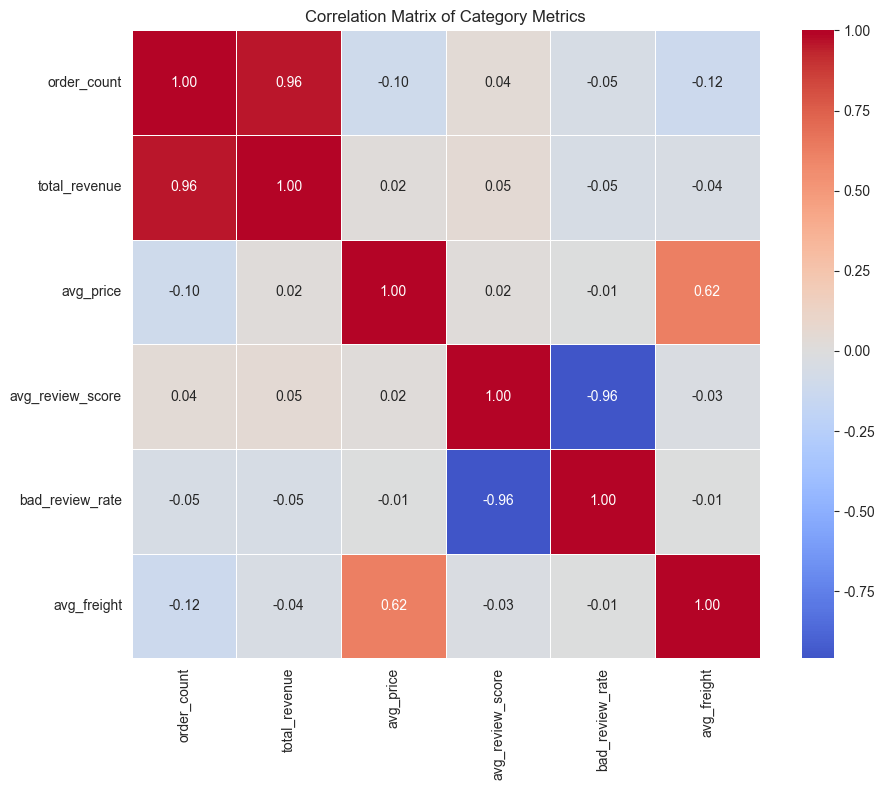

In [102]:
# heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Category Metrics")
plt.tight_layout()
plt.show()

In [103]:
# print selected correlations for easier interpretation
print("order_count vs total_revenue:", corr_matrix.loc["order_count", "total_revenue"])
print("avg_price vs avg_review_score:", corr_matrix.loc["avg_price", "avg_review_score"])
print("bad_review_rate vs avg_review_score:", corr_matrix.loc["bad_review_rate", "avg_review_score"])

order_count vs total_revenue: 0.9598201423128268
avg_price vs avg_review_score: 0.01772658434957481
bad_review_rate vs avg_review_score: -0.9581312404667034


### Correlation Analysis of Category Metrics Analysis
The correlation analysis shows that `order_count` and `total_revenue` are very strongly positively related (**r = 0.96**), which indicates that category revenue is largely driven by sales volume rather than price alone. This confirms the earlier finding that the platform's core revenue categories are also its high-frequency categories.
By contrast, `avg_price` has almost no relationship with `avg_review_score` (**r = 0.02**), suggesting that higher-priced categories do not systematically receive better or worse customer ratings. The strongest relationship in the matrix is the very strong negative correlation between `bad_review_rate` and `avg_review_score` (**r = -0.96**), which is expected because these two metrics reflect opposite sides of customer satisfaction performance.

### 10. Business Insights and Recommendations
After completing category ranking, customer preference analysis, pricing analysis, time-series analysis, geographic analysis, and statistical testing, the final step is to summaries the main business findings and translate them into practical category management insights.

### 10.1 Key Findings Summary
The analysis shows that category sales are highly concentrated. A total of **16 categories** account for around**80%** of total platform revenue, indicating that the platform relies strongly on a limited group of core categories. Among them, `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios` are the most important revenue-driving categories.
The BCG matrix further shows that the category portfolio is split into four strategic groups. Categories such as `beleza_saude`, `esporte_lazer`, `cool_stuff`, and `automotivo` fall into the `Star` group, combining strong revenue performance with above-median satisfaction. By contrast, categories such as `cama_mesa_banho`, `moveis_decoracao`, and `informatica_acessorios` belong to the `Problem` group, meaning that they are commercially important but still face noticeable customer satisfaction risk.

The customer preference analysis suggests that the three RFM clusters share several common core categories, but their internal spending structures are not identical. `Cluster 1` contributes the highest GMV across most major categories, while `cluster 2` shows a more concentrated preference structure, especially in `cama_mesa_banho` and `esporte_lazer`.

Pricing analysis shows that different categories operate in clearly different price bands, and the ANOVA test confirms that category-level price differences are statistically significant. However, the relationship between `avg_price` and `avg_review_score` is extremely weak, suggesting that higher-priced categories do not necessarily receive better customer ratings.

From the time-series perspective, most leading categories show strong growth over time, with many top categories reaching higher sales levels from 2017 onward. Quarterly analysis also suggests that major categories tend to perform relatively better in **Q2**, followed by weaker performance in **Q4**.

The geographic analysis shows that category sales are strongly concentrated in a few major states. `SP` is by far the largest market, followed by `RJ` and `MG`. Although the overall category structure is broadly similar across major states, some categories such as `relogios_presentes`, `moveis_decoracao`, and `informatica_acessorios` show relatively stronger importance in selected regional markets.

### 10.2 Strategic Recommendations

Based on the results of the category analysis, different strategic actions should be applied to different category groups.

For `Star` categories such as `beleza_saude`, `esporte_lazer`, `cool_stuff`, and `automotivo`, the platform should continue to prioritise resource allocation. These categories already combine strong revenue performance with relatively good customer satisfaction, so they should receive stronger inventory support, higher promotional exposure, and more stable supply planning.

For `Problem` categories such as `cama_mesa_banho`, `moveis_decoracao`, and `informatica_acessorios`, the priority should be quality and experience improvement. These categories are major revenue contributors, but their satisfaction performance remains below the median. This means they should be closely monitored in terms of product quality, customer expectation management, logistics, and after-sales service.

For `Opportunity` categories, the focus should be selective growth and targeted promotion. These categories already show relatively good satisfaction but have not yet achieved large revenue scale. Therefore, they may benefit from increased visibility, better recommendation placement, and limited promotional support in order to test whether their commercial potential can be expanded.

For `Dog` categories, the platform should adopt a cautious optimisation strategy. Since these categories are weak in both revenue and satisfaction, they should not receive priority resources unless they serve a special strategic purpose. Instead, they should be reviewed for possible repositioning, limited promotion, or gradual reduction in focus.

### 10.3 KPI Dashboard Summary

To summarise the overall health of the category portfolio, several key indicators can be highlighted as a compact management dashboard. These metrics help translate the analysis into a more business-oriented monitoring view.

- Total number of categories: **73**
- Core categories contributing around 80% of revenue: **16**
- Largest revenue category: `beleza_saude`
- Most important market: `SP`
- Strongest `Star` examples: `beleza_saude`, `esporte_lazer`, `cool_stuff`
- Main `Problem` examples: `cama_mesa_banho`, `moveis_decoracao`, `informatica_acessorios`

Overall, the platform shows a concentrated but commercially strong category structure. The main management challenge is not identifying revenue drivers, but improving customer experience in several high-revenue categories while selectively scaling high-satisfaction opportunity categories.

### 10.4 Conclusion

This project provides a structured analysis of product category performance from multiple perspectives, including sales, customer preference, pricing, time trend, geography, and statistical relationship. The results show that the platform’s category structure is highly concentrated, with a limited number of categories generating most of the revenue.

At the same time, strong revenue performance does not always imply strong customer satisfaction. Several high-revenue categories still face noticeable experience risk, while some smaller categories show relatively high satisfaction and may offer future growth opportunities. Therefore, effective category management should combine revenue focus with customer experience improvement, rather than relying on sales performance alone.

Overall, the analysis suggests that the platform should continue to strengthen its leading categories, improve key problem categories, and selectively support promising opportunity categories. In this way, category strategy can become more balanced, data-driven, and aligned with long-term platform growth.